# MaxViT-T + TabTransformer + Cross-Attention
## ISIC-DICM-17K Multimodal Melanoma Classification

**Architecture:** MaxViT-Tiny backbone (multi-axis self-attention: window + grid) fused with clinical metadata via TabTransformer and bidirectional Cross-Attention.

**XAI Methods:**
1. Grad-CAM / Grad-CAM++ — spatial heatmaps
2. Integrated Gradients (Captum) — pixel + feature attribution
3. LIME — superpixel explanations
4. SHAP KernelExplainer — global clinical feature importance
5. Cross-Attention Maps — which clinical feature attends where
6. PDP Plots — partial dependence of each metadata feature

**Key distinction vs other team models:**
- MaxViT uses *Multi-Axis Self-Attention* (both local window AND global grid attention), unlike EfficientNetV2-S (CNN) or Swin (shifted window only)
- Smaller and faster: 31M params vs 88M for SwinV2-Base
- Different progressive unfreezing strategy (stage-level, not block-level)


In [1]:
!pip install -q timm captum shap scikit-learn lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.6 MB/s eta 0:00:00ta 0:00:01


In [2]:
!pip install captum

In [3]:
# """
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   ISIC-DICM-17K  —  MaxViT-T + TabTransformer + Cross-Attention            ║
# ║                   v1 FINAL  •  6 XAI Methods  •  Kaggle/Colab GPU          ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Architecture:                                                               ║
# ║   • MaxViT-T (maxvit_tiny_tf_224.in1k) — hybrid CNN-Transformer backbone    ║
# ║     with Multi-Axis Self-Attention (window + grid) for long-range context   ║
# ║   • TabTransformer — per-feature embeddings + Transformer for metadata      ║
# ║   • Cross-Attention Fusion — bidirectional: meta queries image tokens       ║
# ║   • Classifier head — LayerNorm → Linear → GELU → Dropout → 2-class out    ║
# ║                                                                              ║
# ║  XAI methods implemented:                                                    ║
# ║   1. Grad-CAM++             — spatial heatmap on last conv layer             ║
# ║   2. Integrated Gradients   — pixel + tabular attribution (Captum)           ║
# ║   3. LIME                   — superpixel-level image explanation             ║
# ║   4. SHAP KernelExplainer   — global clinical feature importance             ║
# ║   5. Cross-Attention Maps   — which clinical feature attends where in image ║
# ║   6. PDP Plots              — how each metadata feature shifts P(Melanoma)   ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Key differences vs EfficientNetV2-S and Swin models:                       ║
# ║   • MaxViT uses multi-axis attention (both local window AND global grid)     ║
# ║     giving it richer spatial reasoning at lower resolution cost than Swin    ║
# ║   • Smaller model (31M params), fast convergence, ideal for medical imaging  ║
# ║   • Larger image size (224) and distinct feature map extraction strategy     ║
# ║   • Attention Rollout applied on MaxViT blocks (not TabTransformer only)    ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# """

# # ── 0. Imports ────────────────────────────────────────────────────────────────
# import os, gc, re, math, warnings
# import numpy as np
# import pandas as pd
# import matplotlib
# import matplotlib.pyplot as plt
# import matplotlib.cm as mpl_cm
# import seaborn as sns
# from PIL import Image
# from tqdm import tqdm
# warnings.filterwarnings("ignore")

# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# from torchvision import transforms
# import timm

# from sklearn.model_selection import StratifiedKFold, train_test_split
# from sklearn.metrics import (
#     roc_auc_score, classification_report,
#     confusion_matrix, roc_curve, f1_score)
# from sklearn.calibration import calibration_curve
# from sklearn.inspection import partial_dependence

# from captum.attr import IntegratedGradients
# from lime import lime_image
# from lime.wrappers.scikit_image import SegmentationAlgorithm
# import shap


# # ── 1. Configuration ──────────────────────────────────────────────────────────
# class CFG:
#     # ── Paths ─────────────────────────────────────────────────────────────────
#     CSV_PATH   = "/kaggle/input/datasets/janaahmedmohamed/final-preprocessed-data-csv/final_preprocessed_data.csv"
#     IMAGES_DIR = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
#     OUTPUT_DIR = "/kaggle/working/maxvit_outputs/"

#     # ── Column names ──────────────────────────────────────────────────────────
#     IMG_COL    = "image"
#     TARGET_COL = "class"

#     DROP_COLS  = [
#         "image", "isic_id", "patient_id", "class",
#         "diagnosis_confirm_type_histopathology",
#         "anatom_site_general_oral/genital",
#         "age_group_0-20", "age_group_21-40",
#         "age_group_41-60", "age_group_61-85",
#         "year",
#     ]

#     # ── Image ─────────────────────────────────────────────────────────────────
#     IMG_SIZE   = 224          # MaxViT-T native resolution
#     MEAN       = [0.485, 0.456, 0.406]
#     STD        = [0.229, 0.224, 0.225]

#     # ── Architecture ──────────────────────────────────────────────────────────
#     D             = 128        # shared embedding dim
#     NUM_HEADS     = 8
#     FF_DIM        = 256
#     NUM_CA_LAYERS = 2
#     DROPOUT_TF    = 0.15
#     TAB_DEPTH     = 2
#     TAB_HEADS     = 4
#     MAXVIT_MODEL  = "maxvit_tiny_tf_224.in1k"

#     # ── Training ──────────────────────────────────────────────────────────────
#     SEED          = 42
#     EPOCHS        = 5
#     BATCH_SIZE    = 16
#     GRAD_ACCUM    = 2
#     NUM_WORKERS   = 2
#     PATIENCE      = 10
#     LABEL_SMOOTH  = 0.10
#     FOCAL_ALPHA   = 0.25
#     FOCAL_GAMMA   = 2.0
#     LR_BACKBONE   = 2e-5
#     LR_HEAD       = 2e-4
#     WEIGHT_DECAY  = 1e-4
#     WARMUP_EPOCHS = 3
#     UNFREEZE_EPOCH_1 = 10    # unfreeze stages 3-4 at epoch 10
#     UNFREEZE_EPOCH_2 = 20    # unfreeze all at epoch 20
#     EMA_ALPHA     = 0.3
#     CUTMIX_PROB   = 0.30
#     MIXUP_PROB    = 0.20
#     CUTMIX_ALPHA  = 1.0
#     MIXUP_ALPHA   = 0.4
#     TTA_STEPS     = 5
#     USE_KFOLD     = False
#     N_FOLDS       = 5

#     # ── XAI ───────────────────────────────────────────────────────────────────
#     XAI_N_SAMPLES      = 5
#     XAI_IG_STEPS       = 25
#     LIME_N_SAMPLES     = 500
#     LIME_N_SEGMENTS    = 60
#     SHAP_BACKGROUND    = 30
#     SHAP_NSAMPLES      = 50
#     SHAP_EXPLAIN       = 15
#     PDP_N_FEATURES     = 6
#     PDP_GRID_POINTS    = 50

#     DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
# torch.manual_seed(CFG.SEED)
# np.random.seed(CFG.SEED)
# print(f"Device : {CFG.DEVICE}")
# print(f"GPU    : {torch.cuda.get_device_name(0) if CFG.DEVICE == 'cuda' else 'N/A'}")


# # ── 2. Feature Validator ──────────────────────────────────────────────────────
# def validate_features(df, meta_cols):
#     print("\n── Feature validation ──")
#     issues = []
#     for c in meta_cols:
#         if df[c].std() == 0:
#             issues.append(f"DEAD COLUMN (zero variance): {c}")
#     for c in meta_cols:
#         r = abs(df[c].corr(df[CFG.TARGET_COL]))
#         if r > 0.45:
#             issues.append(f"LEAKAGE RISK (r={r:.3f} with class): {c}")
#     if issues:
#         for i in issues:
#             print(f"  {i}")
#         raise ValueError("Fix issues above — add column names to CFG.DROP_COLS.")
#     sparse = [(c, (df[c] == 0).mean()) for c in meta_cols
#               if (df[c] == 0).mean() > 0.99]
#     if sparse:
#         print("  Sparse features (>99% zeros) — keeping as missing-data signal:")
#         for c, pct in sparse:
#             print(f"    {c} ({pct*100:.1f}% zeros)")
#     print(f"  Passed — {len(meta_cols)} clean features ready.\n")


# # ── 3. EMA & Threshold helpers ────────────────────────────────────────────────
# class EMAMetric:
#     def __init__(self, alpha=0.3):
#         self.alpha = alpha
#         self.value = None

#     def update(self, v):
#         self.value = v if self.value is None \
#             else self.alpha * v + (1 - self.alpha) * self.value
#         return self.value


# def find_optimal_threshold(labels, probs):
#     fpr, tpr, thresholds = roc_curve(labels, probs)
#     j        = tpr - fpr
#     best_idx = int(np.argmax(j))
#     return float(thresholds[best_idx]), float(j[best_idx])


# # ── 4. Temperature Scaling ────────────────────────────────────────────────────
# class TemperatureScaler(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.temperature = nn.Parameter(torch.ones(1) * 1.5)

#     def forward(self, logits):
#         return logits / self.temperature.clamp(min=0.05)

#     def fit(self, model, loader, device, n_iter=100, lr=0.02):
#         self.to(device)
#         optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=n_iter)
#         all_logits, all_labels = [], []
#         model.eval()
#         with torch.no_grad():
#             for images, metas, labels in loader:
#                 logits = model(images.to(device), metas.to(device))
#                 all_logits.append(logits.cpu())
#                 all_labels.append(labels)
#         all_logits = torch.cat(all_logits).to(device)
#         all_labels = torch.cat(all_labels).to(device)

#         def closure():
#             optimizer.zero_grad()
#             loss = F.cross_entropy(self(all_logits), all_labels)
#             loss.backward()
#             return loss

#         optimizer.step(closure)
#         print(f"  Temperature calibrated → T = {self.temperature.item():.4f}")
#         return self


# # ── 5. Dataset ────────────────────────────────────────────────────────────────
# class ISICDataset(Dataset):
#     def __init__(self, df, images_dir, augment=False):
#         self.df         = df.reset_index(drop=True)
#         self.images_dir = images_dir
#         self.meta_cols  = [c for c in df.columns if c not in CFG.DROP_COLS]
#         self.meta_dim   = len(self.meta_cols)
#         self.augment    = augment

#         if augment:
#             self.transform = transforms.Compose([
#                 transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                 transforms.RandomHorizontalFlip(p=0.5),
#                 transforms.RandomVerticalFlip(p=0.5),
#                 transforms.RandomRotation(degrees=30),
#                 transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
#                 transforms.RandomGrayscale(p=0.1),
#                 transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
#                 transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
#                 transforms.ToTensor(),
#                 transforms.Normalize(CFG.MEAN, CFG.STD),
#                 transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
#             ])
#         else:
#             self.transform = transforms.Compose([
#                 transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                 transforms.ToTensor(),
#                 transforms.Normalize(CFG.MEAN, CFG.STD),
#             ])

#         self.tta_transforms = [
#             transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                                  transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
#             transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                                  transforms.RandomHorizontalFlip(p=1.0),
#                                  transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
#             transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                                  transforms.RandomVerticalFlip(p=1.0),
#                                  transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
#             transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                                  transforms.RandomRotation(degrees=(90, 90)),
#                                  transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
#             transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#                                  transforms.RandomRotation(degrees=(270, 270)),
#                                  transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
#         ]

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row      = self.df.iloc[idx]
#         img_name = str(row[CFG.IMG_COL])
#         img_path = os.path.join(self.images_dir, img_name)
#         if not os.path.exists(img_path):
#             raise FileNotFoundError(f"Missing: {img_path}")
#         image = Image.open(img_path).convert("RGB")
#         image = self.transform(image)
#         meta  = torch.tensor(row[self.meta_cols].values.astype(np.float32), dtype=torch.float32)
#         label = torch.tensor(int(row[CFG.TARGET_COL]), dtype=torch.long)
#         return image, meta, label


# def make_weighted_sampler(labels, epoch=0):
#     class_counts  = np.bincount(labels)
#     class_weights = 1.0 / class_counts
#     sample_w      = class_weights[labels]
#     return WeightedRandomSampler(
#         weights=torch.from_numpy(sample_w).float(),
#         num_samples=len(sample_w),
#         replacement=True,
#         generator=torch.Generator().manual_seed(CFG.SEED + epoch),
#     )


# # ── 6. Augmentation Mix ───────────────────────────────────────────────────────
# def cutmix_batch(images, labels, alpha=1.0):
#     B   = images.size(0)
#     lam = np.random.beta(alpha, alpha)
#     idx = torch.randperm(B)
#     W, H = images.size(3), images.size(2)
#     cut_w, cut_h = int(W * np.sqrt(1 - lam)), int(H * np.sqrt(1 - lam))
#     cx, cy = np.random.randint(W), np.random.randint(H)
#     x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
#     y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
#     images_m = images.clone()
#     images_m[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
#     lam = 1 - ((x2 - x1) * (y2 - y1)) / (W * H)
#     return images_m, labels, labels[idx], lam


# def mixup_batch(images, labels, alpha=0.4):
#     lam = np.random.beta(alpha, alpha)
#     idx = torch.randperm(images.size(0))
#     return lam * images + (1 - lam) * images[idx], labels, labels[idx], lam


# def apply_augmentation_mix(images, labels):
#     rand = np.random.random()
#     if rand < CFG.CUTMIX_PROB:
#         images, la, lb, lam = cutmix_batch(images, labels, CFG.CUTMIX_ALPHA)
#         return images, la, lb, lam, True
#     elif rand < CFG.CUTMIX_PROB + CFG.MIXUP_PROB:
#         images, la, lb, lam = mixup_batch(images, labels, CFG.MIXUP_ALPHA)
#         return images, la, lb, lam, True
#     else:
#         return images, labels, labels, 1.0, False


# # ── 7. Model Components ───────────────────────────────────────────────────────

# class MaxViTEncoder(nn.Module):
#     """
#     MaxViT-T backbone for spatial token extraction.
#     MaxViT uses alternating local-window and global-grid attention (Multi-Axis
#     Self-Attention), giving it the best of CNN efficiency and ViT global context.
#     We extract the feature map from the last stage and project to D-dim tokens.
#     """
#     def __init__(self, out_dim=128, dropout=0.15):
#         super().__init__()
#         # Load MaxViT-T with no classification head, no global pool
#         # feature_only=False, global_pool="" → returns raw feature map
#         self.backbone = timm.create_model(
#             CFG.MAXVIT_MODEL, pretrained=True, num_classes=0, global_pool=""
#         )
#         # Store hooks for intermediate feature maps (for Grad-CAM)
#         self._features = None
#         self._gradients = None

#         # Discover feature map dimensions
#         with torch.no_grad():
#             dummy = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
#             feats = self.backbone(dummy)
#             # MaxViT returns (B, C, H, W) from last stage
#             if feats.dim() == 4:
#                 self.feat_dim = feats.shape[1]
#                 self.feat_h   = feats.shape[2]
#                 self.feat_w   = feats.shape[3]
#             else:
#                 # Some MaxViT variants return (B, C) — reshape via forward_features
#                 feats = self.backbone.forward_features(dummy)
#                 self.feat_dim = feats.shape[-1]
#                 self.feat_h   = int(CFG.IMG_SIZE // 32)
#                 self.feat_w   = int(CFG.IMG_SIZE // 32)
#             print(f"  MaxViT-T feature map: "
#                   f"{self.feat_dim}×{self.feat_h}×{self.feat_w} "
#                   f"→ {self.feat_h * self.feat_w} spatial tokens")

#         # Project to shared dim D
#         self.proj = nn.Sequential(
#             nn.Conv2d(self.feat_dim, out_dim, kernel_size=1, bias=False),
#             nn.BatchNorm2d(out_dim), nn.GELU(), nn.Dropout2d(dropout),
#         )
#         n_patches    = self.feat_h * self.feat_w
#         self.pos_emb = nn.Parameter(torch.zeros(1, n_patches, out_dim))
#         nn.init.trunc_normal_(self.pos_emb, std=0.02)
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, out_dim))
#         nn.init.trunc_normal_(self.cls_token, std=0.02)

#         # Freeze early stages by default
#         self._freeze_stages(2)

#     def _freeze_stages(self, n_stages):
#         """Freeze first n_stages of MaxViT."""
#         # MaxViT stages are in backbone.stages
#         stages = list(self.backbone.stages.children()) if hasattr(self.backbone, 'stages') else []
#         for i, stage in enumerate(stages):
#             if i < n_stages:
#                 for param in stage.parameters():
#                     param.requires_grad = False
#         # Also freeze stem
#         if hasattr(self.backbone, 'stem'):
#             for param in self.backbone.stem.parameters():
#                 param.requires_grad = False
#         trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
#         print(f"  Frozen first {n_stages} stages | trainable backbone params: {trainable:,}")

#     def unfreeze_stages(self, from_stage, to_stage):
#         """Progressively unfreeze MaxViT stages for fine-tuning."""
#         stages = list(self.backbone.stages.children()) if hasattr(self.backbone, 'stages') else []
#         for i, stage in enumerate(stages):
#             if from_stage <= i < to_stage:
#                 for param in stage.parameters():
#                     param.requires_grad = True
#         trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
#         print(f"  🔓 Unfroze stages {from_stage}–{to_stage-1} | trainable: {trainable:,}")

#     def get_newly_unfrozen_params(self, from_stage, to_stage):
#         stages = list(self.backbone.stages.children()) if hasattr(self.backbone, 'stages') else []
#         params = []
#         for i, stage in enumerate(stages):
#             if from_stage <= i < to_stage:
#                 params += [p for p in stage.parameters() if p.requires_grad]
#         return params

#     def forward(self, x):
#         feats = self.backbone(x)
#         if feats.dim() == 3:
#             # (B, HW, C) → (B, C, H, W)
#             B, HW, C = feats.shape
#             H = W = int(math.sqrt(HW))
#             feats = feats.transpose(1, 2).reshape(B, C, H, W)
#         tokens = self.proj(feats)        # (B, D, H, W)
#         B, D, H, W = tokens.shape
#         tokens = tokens.flatten(2).transpose(1, 2)   # (B, H*W, D)
#         tokens = tokens + self.pos_emb
#         cls    = self.cls_token.expand(B, -1, -1)
#         return torch.cat([cls, tokens], dim=1)       # (B, 1+H*W, D)


# class TabTransformerEncoder(nn.Module):
#     """
#     Per-feature linear projection + positional embedding + Transformer encoder.
#     Each clinical feature becomes one token. CLS token aggregates metadata.
#     """
#     def __init__(self, num_features, embed_dim=128, depth=2,
#                  num_heads=4, ff_dim=256, dropout=0.15):
#         super().__init__()
#         self.num_features = num_features
#         self.feature_embeddings = nn.ModuleList([
#             nn.Sequential(nn.Linear(1, embed_dim), nn.LayerNorm(embed_dim))
#             for _ in range(num_features)
#         ])
#         self.pos_emb   = nn.Parameter(torch.zeros(1, num_features, embed_dim))
#         self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
#         nn.init.trunc_normal_(self.pos_emb,   std=0.02)
#         nn.init.trunc_normal_(self.cls_token, std=0.02)
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
#             dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
#         self.norm        = nn.LayerNorm(embed_dim)

#     def forward(self, x):
#         B      = x.size(0)
#         tokens = torch.stack([
#             self.feature_embeddings[i](x[:, i:i+1])
#             for i in range(self.num_features)
#         ], dim=1)
#         tokens = tokens + self.pos_emb
#         cls    = self.cls_token.expand(B, -1, -1)
#         tokens = torch.cat([cls, tokens], dim=1)
#         tokens = self.transformer(tokens)
#         return self.norm(tokens)


# class CrossAttentionBlock(nn.Module):
#     """
#     Bidirectional cross-attention fusion:
#       • Image tokens self-attend  (local spatial context)
#       • Meta tokens attend image  (clinical features query visual regions)
#     Per-head attention weights stored for XAI cross-attention maps.
#     """
#     def __init__(self, dim, num_heads, ff_dim, dropout=0.15):
#         super().__init__()
#         self.meta_to_img = nn.MultiheadAttention(
#             embed_dim=dim, num_heads=num_heads,
#             dropout=dropout, batch_first=True,
#         )
#         self.img_self_attn = nn.MultiheadAttention(
#             embed_dim=dim, num_heads=num_heads,
#             dropout=dropout, batch_first=True,
#         )
#         self.ffn_meta = nn.Sequential(
#             nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
#             nn.GELU(), nn.Dropout(dropout),
#             nn.Linear(ff_dim, dim), nn.Dropout(dropout),
#         )
#         self.ffn_img  = nn.Sequential(
#             nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
#             nn.GELU(), nn.Dropout(dropout),
#             nn.Linear(ff_dim, dim), nn.Dropout(dropout),
#         )
#         self.norm_img  = nn.LayerNorm(dim)
#         self.norm_meta = nn.LayerNorm(dim)

#     def forward(self, img_tokens, meta_tokens, need_attn_weights=False):
#         # Image self-attention
#         img_sa, _ = self.img_self_attn(
#             query=self.norm_img(img_tokens),
#             key=img_tokens, value=img_tokens, need_weights=False,
#         )
#         img_tokens  = img_tokens + img_sa
#         img_tokens  = img_tokens + self.ffn_img(img_tokens)

#         # Cross-attention: meta tokens (query) attend to image tokens (key/value)
#         # average_attn_weights=False → shape (B, num_heads, n_meta, n_img)
#         meta_ca, attn_weights = self.meta_to_img(
#             query=self.norm_meta(meta_tokens),
#             key=img_tokens, value=img_tokens,
#             need_weights=True,
#             average_attn_weights=False,
#         )
#         meta_tokens = meta_tokens + meta_ca
#         meta_tokens = meta_tokens + self.ffn_meta(meta_tokens)

#         return img_tokens, meta_tokens, attn_weights   # (B, H, n_meta, n_img)


# class MaxViTFusionModel(nn.Module):
#     """
#     Full multimodal model:
#       MaxViT-T → spatial image tokens
#       TabTransformer → clinical metadata tokens
#       N × CrossAttentionBlock → fused representations
#       Classifier → 2-class output (Non-Melanoma / Melanoma)
#     """
#     def __init__(self, meta_dim):
#         super().__init__()
#         D = CFG.D
#         self.img_encoder  = MaxViTEncoder(out_dim=D, dropout=CFG.DROPOUT_TF)
#         self.meta_encoder = TabTransformerEncoder(
#             num_features=meta_dim, embed_dim=D, depth=CFG.TAB_DEPTH,
#             num_heads=CFG.TAB_HEADS, ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF,
#         )
#         self.ca_layers = nn.ModuleList([
#             CrossAttentionBlock(dim=D, num_heads=CFG.NUM_HEADS,
#                                 ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF)
#             for _ in range(CFG.NUM_CA_LAYERS)
#         ])
#         self.classifier = nn.Sequential(
#             nn.LayerNorm(D * 2), nn.Linear(D * 2, 256),
#             nn.GELU(), nn.Dropout(0.4),
#             nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
#             nn.Linear(128, 2),
#         )
#         self._ca_weights_per_layer = []
#         total_p    = sum(p.numel() for p in self.parameters())
#         trainable_p = sum(p.numel() for p in self.parameters() if p.requires_grad)
#         print(f"  Total params    : {total_p:,}")
#         print(f"  Trainable params: {trainable_p:,}")

#     def forward(self, image, meta):
#         img_tokens  = self.img_encoder(image)
#         meta_tokens = self.meta_encoder(meta)
#         self._ca_weights_per_layer = []
#         for ca in self.ca_layers:
#             img_tokens, meta_tokens, attn = ca(img_tokens, meta_tokens,
#                                                need_attn_weights=True)
#             self._ca_weights_per_layer.append(attn.detach())
#         img_cls  = img_tokens[:, 0, :]
#         meta_cls = meta_tokens[:, 0, :]
#         fused    = torch.cat([img_cls, meta_cls], dim=1)
#         return self.classifier(fused)

#     def get_cross_attention(self, layer=-1):
#         return self._ca_weights_per_layer[layer]   # (B, H, n_meta, n_img)

#     def unfreeze_backbone_stages(self, from_stage, to_stage):
#         self.img_encoder.unfreeze_stages(from_stage, to_stage)

#     def get_newly_unfrozen_params(self, from_stage, to_stage):
#         return self.img_encoder.get_newly_unfrozen_params(from_stage, to_stage)


# # ── 8. Loss Functions ─────────────────────────────────────────────────────────
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
#         super().__init__()
#         self.alpha     = alpha
#         self.gamma     = gamma
#         self.smoothing = smoothing

#     def forward(self, logits, targets):
#         n  = logits.size(1)
#         lp = F.log_softmax(logits, dim=1)
#         with torch.no_grad():
#             s = torch.full_like(lp, self.smoothing / (n - 1))
#             s.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
#         ce   = -(s * lp).sum(dim=1)
#         pt   = torch.exp(-ce)
#         return (self.alpha * (1 - pt) ** self.gamma * ce).mean()


# class MixLoss(nn.Module):
#     def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
#         super().__init__()
#         self.focal = FocalLoss(alpha, gamma, smoothing)

#     def forward(self, logits, targets_a, targets_b=None, lam=1.0):
#         if targets_b is None or lam == 1.0:
#             return self.focal(logits, targets_a)
#         return lam * self.focal(logits, targets_a) + (1 - lam) * self.focal(logits, targets_b)


# # ── 9. LR Scheduler ───────────────────────────────────────────────────────────
# class WarmupCosineScheduler:
#     def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
#         self.opt           = optimizer
#         self.warmup_epochs = warmup_epochs
#         self.total_epochs  = total_epochs
#         self.min_lr        = min_lr
#         self.base_lrs      = [pg["lr"] for pg in optimizer.param_groups]

#     def add_new_param_group(self, lr):
#         self.base_lrs.append(lr)

#     def step(self, epoch):
#         e = epoch - 1
#         if e < self.warmup_epochs:
#             scale = max(0.01, (e + 1) / self.warmup_epochs)
#         else:
#             progress  = (e - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
#             min_scale = self.min_lr / max(self.base_lrs)
#             scale     = max(0.5 * (1 + math.cos(math.pi * progress)), min_scale)
#         for pg, base in zip(self.opt.param_groups, self.base_lrs):
#             pg["lr"] = base * scale

#     def get_lr(self):
#         return [pg["lr"] for pg in self.opt.param_groups]


# # ── 10. Train / Eval Loops ────────────────────────────────────────────────────
# def train_one_epoch(model, loader, optimizer, criterion, scaler_amp, device):
#     model.train()
#     total_loss = 0
#     all_labels, all_probs = [], []
#     optimizer.zero_grad()

#     for step, (images, metas, labels) in enumerate(tqdm(loader, desc="  Train", leave=False)):
#         images = images.to(device, non_blocking=True)
#         metas  = metas.to(device,  non_blocking=True)
#         labels = labels.to(device, non_blocking=True)
#         images, la, lb, lam, use_mix = apply_augmentation_mix(images, labels)

#         with torch.amp.autocast("cuda", enabled=(device == "cuda")):
#             logits = model(images, metas)
#             loss   = criterion(logits, la, lb if use_mix else None, lam) / CFG.GRAD_ACCUM

#         scaler_amp.scale(loss).backward()
#         if (step + 1) % CFG.GRAD_ACCUM == 0:
#             scaler_amp.unscale_(optimizer)
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
#             scaler_amp.step(optimizer)
#             scaler_amp.update()
#             optimizer.zero_grad()

#         total_loss += loss.item() * CFG.GRAD_ACCUM * images.size(0)
#         probs = torch.softmax(logits, dim=1)[:, 1].detach().float().cpu().numpy()
#         all_probs.extend(probs)
#         all_labels.extend(la.cpu().numpy())

#     avg_loss = total_loss / len(loader.dataset)
#     auc      = roc_auc_score(all_labels, all_probs)
#     return avg_loss, auc


# @torch.no_grad()
# def evaluate(model, loader, criterion, device, threshold=0.5, temperature_scaler=None):
#     model.eval()
#     total_loss = 0
#     all_labels, all_probs = [], []

#     for images, metas, labels in tqdm(loader, desc="  Val  ", leave=False):
#         images = images.to(device, non_blocking=True)
#         metas  = metas.to(device,  non_blocking=True)
#         labels = labels.to(device, non_blocking=True)

#         with torch.amp.autocast("cuda", enabled=(device == "cuda")):
#             logits = model(images, metas)
#             if temperature_scaler is not None:
#                 logits = temperature_scaler(logits)
#             loss   = criterion(logits, labels)

#         total_loss += loss.item() * images.size(0)
#         probs  = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
#         all_probs.extend(probs)
#         all_labels.extend(labels.cpu().numpy())

#     labels_np = np.array(all_labels)
#     probs_np  = np.array(all_probs)
#     preds_np  = (probs_np >= threshold).astype(int)
#     auc       = roc_auc_score(labels_np, probs_np)
#     f1        = f1_score(labels_np, preds_np, average="macro")
#     return total_loss / len(loader.dataset), auc, f1, labels_np, preds_np, probs_np


# @torch.no_grad()
# def evaluate_with_tta(model, dataset, criterion, device, threshold=0.5,
#                       temperature_scaler=None):
#     """Test-Time Augmentation: average predictions over multiple augmentations."""
#     model.eval()
#     all_probs_tta = []
#     all_labels = []

#     for idx in tqdm(range(len(dataset)), desc="  TTA ", leave=False):
#         _, meta, label = dataset[idx]
#         row       = dataset.df.iloc[idx]
#         img_name  = str(row[CFG.IMG_COL])
#         img_path  = os.path.join(dataset.images_dir, img_name)
#         img_pil   = Image.open(img_path).convert("RGB")

#         probs_list = []
#         for tf in dataset.tta_transforms:
#             img_t  = tf(img_pil).unsqueeze(0).to(device)
#             meta_t = meta.unsqueeze(0).to(device)
#             logit  = model(img_t, meta_t)
#             if temperature_scaler is not None:
#                 logit = temperature_scaler(logit)
#             p = torch.softmax(logit, dim=1)[0, 1].item()
#             probs_list.append(p)

#         all_probs_tta.append(np.mean(probs_list))
#         all_labels.append(int(label.item()))

#     labels_np = np.array(all_labels)
#     probs_np  = np.array(all_probs_tta)
#     preds_np  = (probs_np >= threshold).astype(int)
#     auc       = roc_auc_score(labels_np, probs_np)
#     f1        = f1_score(labels_np, preds_np, average="macro")
#     return auc, f1, labels_np, preds_np, probs_np


# # ── 11. Plot Helpers ──────────────────────────────────────────────────────────
# def plot_training_history(history, save_path):
#     epochs = range(1, len(history["train_loss"]) + 1)
#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#     fig.suptitle("MaxViT-T + TabTransformer + Cross-Attention — Training History",
#                  fontsize=14, fontweight="bold")

#     axes[0].plot(epochs, history["train_loss"], "b-o", ms=4, label="Train")
#     axes[0].plot(epochs, history["val_loss"],   "r-o", ms=4, label="Val")
#     axes[0].set_title("Focal Loss"); axes[0].set_xlabel("Epoch")
#     axes[0].legend(); axes[0].grid(alpha=0.3)

#     axes[1].plot(epochs, history["train_auc"],  "b-o", ms=4, label="Train")
#     axes[1].plot(epochs, history["val_auc"],    "r-o", ms=4, label="Val")
#     axes[1].plot(epochs, history["ema_auc"],    "g--", ms=3, label="EMA Val")
#     axes[1].set_title("AUC-ROC"); axes[1].set_xlabel("Epoch")
#     axes[1].legend(); axes[1].grid(alpha=0.3)

#     axes[2].plot(epochs, history["val_f1"],     "m-o", ms=4, label="F1 Macro")
#     axes[2].plot(epochs, history["threshold"],  "k--", ms=3, label="Threshold")
#     axes[2].set_title("F1 & Threshold"); axes[2].set_xlabel("Epoch")
#     axes[2].legend(); axes[2].grid(alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(save_path, dpi=150, bbox_inches="tight")
#     plt.show(); plt.close(fig)
#     print(f"  ✔ Saved: {save_path}")


# def plot_confusion_matrix(cm_arr, labels=["Non-Melanoma", "Melanoma"], save_path=None):
#     fig, ax = plt.subplots(figsize=(6, 5))
#     sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues",
#                 xticklabels=labels, yticklabels=labels, ax=ax)
#     ax.set_xlabel("Predicted"); ax.set_ylabel("True")
#     ax.set_title("Confusion Matrix — MaxViT-T Fusion")
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches="tight")
#     plt.show(); plt.close(fig)


# def plot_roc(labels, probs, auc_val, save_path=None):
#     fpr, tpr, _ = roc_curve(labels, probs)
#     fig, ax = plt.subplots(figsize=(6, 6))
#     ax.plot(fpr, tpr, "b-", lw=2, label=f"AUC = {auc_val:.4f}")
#     ax.plot([0, 1], [0, 1], "k--", lw=1)
#     ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
#     ax.set_title("ROC Curve — MaxViT-T Fusion")
#     ax.legend(loc="lower right"); ax.grid(alpha=0.3)
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches="tight")
#     plt.show(); plt.close(fig)


# def plot_calibration(labels, probs, save_path=None):
#     fraction_pos, mean_pred = calibration_curve(labels, probs, n_bins=10)
#     fig, ax = plt.subplots(figsize=(6, 5))
#     ax.plot(mean_pred, fraction_pos, "s-b", label="MaxViT-T Fusion (calibrated)")
#     ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
#     ax.set_xlabel("Mean predicted probability")
#     ax.set_ylabel("Fraction of positives")
#     ax.set_title("Calibration Curve"); ax.legend(); ax.grid(alpha=0.3)
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=150, bbox_inches="tight")
#     plt.show(); plt.close(fig)


# # ═══════════════════════════════════════════════════════════════════════════════
# #  XAI SECTION — 6 Methods
# # ═══════════════════════════════════════════════════════════════════════════════

# _XAI_TF = transforms.Compose([
#     transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(CFG.MEAN, CFG.STD),
# ])

# def _norm01(x):
#     mn, mx = x.min(), x.max()
#     return (x - mn) / (mx - mn + 1e-8)

# def _resize_map(arr2d, size):
#     pil = Image.fromarray((_norm01(arr2d) * 255).astype(np.uint8))
#     return np.array(pil.resize((size, size), Image.BILINEAR)) / 255.0

# def _overlay(rgb, heatmap, alpha=0.5):
#     colored = mpl_cm.get_cmap("jet")(heatmap)[..., :3]
#     return np.clip((1 - alpha) * rgb + alpha * colored, 0, 1)

# def _save(fig, name):
#     path = os.path.join(CFG.OUTPUT_DIR, name)
#     fig.savefig(path, dpi=150, bbox_inches="tight")
#     plt.show(); plt.close(fig)
#     print(f"  ✔ {path}")

# def _xai_load(img_name_or_path, meta_series):
#     raw  = str(img_name_or_path).split("/")[-1]
#     m    = re.search(r"(\d{7})", raw)
#     name = f"ISIC_{m.group(1)}.jpg" if m else raw
#     path = os.path.join(CFG.IMAGES_DIR, name)
#     if not os.path.exists(path):
#         raise FileNotFoundError(f"XAI image not found: {path}")
#     img = Image.open(path).convert("RGB")
#     it  = _XAI_TF(img).unsqueeze(0).to(CFG.DEVICE)
#     mt  = torch.tensor(meta_series.values.astype(np.float32),
#                        dtype=torch.float32).unsqueeze(0).to(CFG.DEVICE)
#     rgb = it.squeeze().cpu().permute(1, 2, 0).numpy() * np.array(CFG.STD) + np.array(CFG.MEAN)
#     return it, mt, np.clip(rgb, 0, 1), path


# # ── XAI Method 1 & 2: Grad-CAM and Grad-CAM++ ────────────────────────────────
# def _get_last_conv(model):
#     """Find the last Conv2d in the MaxViT backbone (for Grad-CAM hook)."""
#     last = None
#     for m in model.img_encoder.backbone.modules():
#         if isinstance(m, nn.Conv2d):
#             last = m
#     return last


# class _GradCAMEngine:
#     def __init__(self, model, plus_plus=False):
#         self.model     = model
#         self.plus_plus = plus_plus
#         self._acts = self._grads = None
#         tl = _get_last_conv(model)
#         self._fh = tl.register_forward_hook(
#             lambda m, i, o: setattr(self, "_acts", o.detach()))
#         self._bh = tl.register_full_backward_hook(
#             lambda m, gi, go: setattr(self, "_grads", go[0].detach()))

#     def remove(self):
#         self._fh.remove(); self._bh.remove()

#     def __call__(self, img_t, meta_t, class_idx=1):
#         self.model.zero_grad()
#         logits = self.model(img_t, meta_t)
#         logits[0, class_idx].backward()
#         g, a = self._grads, self._acts
#         if self.plus_plus:
#             g2, g3 = g ** 2, g ** 3
#             denom  = 2 * g2 + g3 * a.sum(dim=(2, 3), keepdim=True) + 1e-8
#             w      = (g2 / denom * F.relu(g)).sum(dim=(2, 3), keepdim=True)
#         else:
#             w = g.mean(dim=(2, 3), keepdim=True)
#         cam = F.relu((w * a).sum(dim=1).squeeze())
#         return _norm01(cam.cpu().numpy())


# def xai_gradcam(model, img_t, meta_t, rgb, save_tag="", class_idx=1):
#     """XAI Method 1 & 2: Grad-CAM and Grad-CAM++ side-by-side."""
#     S = rgb.shape[0]
#     gc_eng = _GradCAMEngine(model, plus_plus=False)
#     gc_map = gc_eng(img_t.clone(), meta_t.clone(), class_idx)
#     gc_eng.remove()
#     pp_eng = _GradCAMEngine(model, plus_plus=True)
#     pp_map = pp_eng(img_t.clone(), meta_t.clone(), class_idx)
#     pp_eng.remove()

#     with torch.no_grad():
#         prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

#     fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#     axes[0].imshow(rgb);                                            axes[0].set_title("Original image")
#     axes[1].imshow(_overlay(rgb, _resize_map(gc_map,  S)));         axes[1].set_title("Grad-CAM")
#     axes[2].imshow(_overlay(rgb, _resize_map(pp_map,  S)));         axes[2].set_title("Grad-CAM++")
#     for ax in axes: ax.axis("off")
#     fig.suptitle(f"Grad-CAM family  |  P(Melanoma) = {prob:.3f}", fontsize=13, fontweight="bold")
#     plt.tight_layout()
#     _save(fig, f"xai_gradcam{save_tag}.png")
#     return gc_map, pp_map


# def run_xai_gradcam(model, val_df, meta_cols, n=None):
#     """Run Grad-CAM / Grad-CAM++ on n samples."""
#     n = n or CFG.XAI_N_SAMPLES
#     print(f"\n{'='*60}\n  XAI Method 1&2: Grad-CAM / Grad-CAM++ ({n} samples)\n{'='*60}")
#     model.eval()
#     idxs = val_df.sample(n=n, random_state=CFG.SEED).index.tolist()
#     for i, idx in enumerate(idxs):
#         row = val_df.loc[idx]
#         img_t, meta_t, rgb, path = _xai_load(row[CFG.IMG_COL], row[meta_cols])
#         label_str = "Melanoma" if int(row[CFG.TARGET_COL]) == 1 else "Non-Melanoma"
#         print(f"  [{i+1}/{n}] {os.path.basename(path)} | True: {label_str}")
#         xai_gradcam(model, img_t, meta_t, rgb, save_tag=f"_s{i}")
#         del img_t, meta_t; gc.collect()


# # ── XAI Method 3: Integrated Gradients ───────────────────────────────────────
# def xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols,
#                               save_tag="", class_idx=1):
#     """
#     XAI Method 3: Integrated Gradients via Captum.
#     Computes pixel-level attributions for the image and
#     per-feature attributions for clinical metadata.
#     """
#     model.eval()

#     class _WrapImg(nn.Module):
#         """Wrapper: fix meta, expose only image tensor as input."""
#         def __init__(self, m, mt):
#             super().__init__()
#             self.m = m; self.mt = mt
#         def forward(self, x):
#             return self.m(x, self.mt)

#     class _WrapMeta(nn.Module):
#         """Wrapper: fix image, expose only meta tensor as input."""
#         def __init__(self, m, it):
#             super().__init__()
#             self.m = m; self.it = it
#         def forward(self, x):
#             return self.m(self.it, x)

#     S = rgb.shape[0]

#     # Image IG
#     wrap_img = _WrapImg(model, meta_t)
#     ig_img   = IntegratedGradients(wrap_img)
#     baseline = torch.zeros_like(img_t)
#     attr_img = ig_img.attribute(img_t, baseline, target=class_idx,
#                                  n_steps=CFG.XAI_IG_STEPS)
#     attr_map = attr_img.squeeze().cpu().permute(1, 2, 0).numpy()
#     attr_map = np.abs(attr_map).mean(axis=2)

#     # Meta IG
#     wrap_meta = _WrapMeta(model, img_t)
#     ig_meta   = IntegratedGradients(wrap_meta)
#     baseline_m = torch.zeros_like(meta_t)
#     attr_meta  = ig_meta.attribute(meta_t, baseline_m, target=class_idx,
#                                     n_steps=CFG.XAI_IG_STEPS)
#     meta_attr_vals = attr_meta.squeeze().detach().cpu().numpy()

#     with torch.no_grad():
#         prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#     axes[0].imshow(rgb); axes[0].set_title("Original image"); axes[0].axis("off")
#     axes[1].imshow(_overlay(rgb, _resize_map(attr_map, S)))
#     axes[1].set_title("IG — pixel attribution"); axes[1].axis("off")

#     # Bar chart for metadata
#     sorted_idx  = np.argsort(np.abs(meta_attr_vals))[::-1][:15]
#     top_names   = [meta_cols[j] for j in sorted_idx]
#     top_vals    = meta_attr_vals[sorted_idx]
#     colors      = ["#d62728" if v > 0 else "#1f77b4" for v in top_vals]
#     axes[2].barh(range(len(top_names)), top_vals[::-1], color=colors[::-1])
#     axes[2].set_yticks(range(len(top_names)))
#     axes[2].set_yticklabels(top_names[::-1], fontsize=8)
#     axes[2].set_title("IG — clinical feature attribution")
#     axes[2].axvline(0, color="black", linewidth=0.8)
#     axes[2].grid(axis="x", alpha=0.3)

#     fig.suptitle(f"Integrated Gradients  |  P(Melanoma) = {prob:.3f}",
#                  fontsize=13, fontweight="bold")
#     plt.tight_layout()
#     _save(fig, f"xai_ig{save_tag}.png")
#     return attr_map, meta_attr_vals


# def run_xai_integrated_gradients(model, val_df, meta_cols, n=None):
#     n = n or CFG.XAI_N_SAMPLES
#     print(f"\n{'='*60}\n  XAI Method 3: Integrated Gradients ({n} samples)\n{'='*60}")
#     model.eval()
#     idxs = val_df.sample(n=n, random_state=CFG.SEED + 1).index.tolist()
#     for i, idx in enumerate(idxs):
#         row = val_df.loc[idx]
#         img_t, meta_t, rgb, path = _xai_load(row[CFG.IMG_COL], row[meta_cols])
#         label_str = "Melanoma" if int(row[CFG.TARGET_COL]) == 1 else "Non-Melanoma"
#         print(f"  [{i+1}/{n}] {os.path.basename(path)} | True: {label_str}")
#         xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols, save_tag=f"_s{i}")
#         del img_t, meta_t; gc.collect()


# # ── XAI Method 4: LIME ────────────────────────────────────────────────────────
# def xai_lime(model, img_t, meta_t, rgb, save_tag="", class_idx=1):
#     """
#     XAI Method 4: LIME superpixel-level image explanation.
#     Perturbs superpixels, fits a local linear model, ranks which
#     regions push P(Melanoma) up or down.
#     """
#     S = rgb.shape[0]

#     def predict_fn(imgs_np):
#         """imgs_np: (N, H, W, 3) uint8 or float."""
#         tf = transforms.Compose([
#             transforms.ToTensor(),
#             transforms.Normalize(CFG.MEAN, CFG.STD),
#         ])
#         model.eval()
#         preds = []
#         with torch.no_grad():
#             for img_np in imgs_np:
#                 img_pil = Image.fromarray((img_np * 255).astype(np.uint8)
#                                           if img_np.max() <= 1 else img_np.astype(np.uint8))
#                 img_pil = img_pil.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
#                 t   = tf(img_pil).unsqueeze(0).to(CFG.DEVICE)
#                 out = torch.softmax(model(t, meta_t), dim=1).cpu().numpy()[0]
#                 preds.append(out)
#         return np.array(preds)

#     explainer = lime_image.LimeImageExplainer(random_state=CFG.SEED)
#     seg       = SegmentationAlgorithm(
#         "quickshift", kernel_size=4, max_dist=200, ratio=0.2, random_seed=CFG.SEED
#     )
#     rgb_uint8 = (rgb * 255).astype(np.uint8)
#     explanation = explainer.explain_instance(
#         rgb_uint8, predict_fn,
#         top_labels=2,
#         num_samples=CFG.LIME_N_SAMPLES,
#         num_features=CFG.LIME_N_SEGMENTS,
#         segmentation_fn=seg,
#         random_seed=CFG.SEED,
#     )

#     # Positive superpixels (pro-melanoma), top 10
#     pos_mask, neg_mask = explanation.get_image_and_mask(
#         label=class_idx, positive_only=True,  num_features=10, hide_rest=False
#     )
#     pos_mask2, neg_mask2 = explanation.get_image_and_mask(
#         label=class_idx, positive_only=False, num_features=10, hide_rest=False
#     )

#     with torch.no_grad():
#         prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

#     fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#     axes[0].imshow(rgb); axes[0].set_title("Original image"); axes[0].axis("off")
#     from skimage.segmentation import mark_boundaries
#     axes[1].imshow(mark_boundaries(pos_mask / 255, neg_mask))
#     axes[1].set_title("LIME — positive superpixels"); axes[1].axis("off")
#     axes[2].imshow(mark_boundaries(pos_mask2 / 255, neg_mask2))
#     axes[2].set_title("LIME — pos + neg superpixels"); axes[2].axis("off")

#     fig.suptitle(f"LIME  |  P(Melanoma) = {prob:.3f}", fontsize=13, fontweight="bold")
#     plt.tight_layout()
#     _save(fig, f"xai_lime{save_tag}.png")


# def run_xai_lime(model, val_df, meta_cols, n=None):
#     n = n or CFG.XAI_N_SAMPLES
#     print(f"\n{'='*60}\n  XAI Method 4: LIME ({n} samples)\n{'='*60}")
#     model.eval()
#     idxs = val_df.sample(n=n, random_state=CFG.SEED + 2).index.tolist()
#     for i, idx in enumerate(idxs):
#         row = val_df.loc[idx]
#         img_t, meta_t, rgb, path = _xai_load(row[CFG.IMG_COL], row[meta_cols])
#         label_str = "Melanoma" if int(row[CFG.TARGET_COL]) == 1 else "Non-Melanoma"
#         print(f"  [{i+1}/{n}] {os.path.basename(path)} | True: {label_str}")
#         xai_lime(model, img_t, meta_t, rgb, save_tag=f"_s{i}")
#         del img_t, meta_t; gc.collect()


# # ── XAI Method 5: SHAP KernelExplainer ───────────────────────────────────────
# def run_xai_shap(model, val_df, meta_cols, n_bg=None, n_explain=None):
#     """
#     XAI Method 5: SHAP KernelExplainer for global clinical feature importance.
#     Uses a background dataset to estimate expected output and explains
#     metadata features. Produces bar plot + beeswarm summary plot.
#     """
#     n_bg      = n_bg      or CFG.SHAP_BACKGROUND
#     n_explain = n_explain or CFG.SHAP_EXPLAIN
#     print(f"\n{'='*60}\n  XAI Method 5: SHAP KernelExplainer\n{'='*60}")
#     model.eval()

#     # Sample background and explain sets
#     bg_df  = val_df.sample(n=n_bg,      random_state=CFG.SEED).reset_index(drop=True)
#     ex_df  = val_df.sample(n=n_explain, random_state=CFG.SEED + 5).reset_index(drop=True)

#     bg_meta  = bg_df[meta_cols].values.astype(np.float32)
#     ex_meta  = ex_df[meta_cols].values.astype(np.float32)

#     # Wrapper: fixed image (use mean image), vary only metadata
#     mean_img = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE)

#     def shap_fn(meta_np):
#         preds = []
#         batch_size = 8
#         with torch.no_grad():
#             for start in range(0, len(meta_np), batch_size):
#                 batch = torch.tensor(meta_np[start:start+batch_size],
#                                      dtype=torch.float32, device=CFG.DEVICE)
#                 img_b = mean_img.expand(len(batch), -1, -1, -1)
#                 out   = torch.softmax(model(img_b, batch), dim=1)[:, 1].cpu().numpy()
#                 preds.extend(out)
#         return np.array(preds)

#     print(f"  Computing SHAP (bg={n_bg}, explain={n_explain}) ...")
#     explainer   = shap.KernelExplainer(shap_fn, bg_meta)
#     shap_values = explainer.shap_values(ex_meta, nsamples=CFG.SHAP_NSAMPLES)

#     # Bar plot — mean |SHAP|
#     shap_abs = np.abs(shap_values)
#     mean_abs = shap_abs.mean(axis=0)
#     sorted_i = np.argsort(mean_abs)[::-1]
#     top_n    = min(15, len(meta_cols))

#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#     axes[0].barh(range(top_n), mean_abs[sorted_i[:top_n]][::-1], color="#2196F3")
#     axes[0].set_yticks(range(top_n))
#     axes[0].set_yticklabels([meta_cols[j] for j in sorted_i[:top_n]][::-1], fontsize=8)
#     axes[0].set_title("SHAP — Mean |SHAP| (global importance)")
#     axes[0].set_xlabel("Mean |SHAP value|")
#     axes[0].grid(axis="x", alpha=0.3)

#     # Beeswarm-style dot plot
#     for rank, feat_i in enumerate(sorted_i[:top_n]):
#         vals = shap_values[:, feat_i]
#         raw  = ex_meta[:, feat_i]
#         norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)
#         sc   = axes[1].scatter(vals, [top_n - 1 - rank] * len(vals),
#                                c=norm, cmap="RdBu_r", alpha=0.7, s=20,
#                                vmin=0, vmax=1)
#     plt.colorbar(sc, ax=axes[1], label="Feature value (normalised)")
#     axes[1].set_yticks(range(top_n))
#     axes[1].set_yticklabels([meta_cols[j] for j in sorted_i[:top_n]][::-1], fontsize=8)
#     axes[1].axvline(0, color="black", lw=0.8)
#     axes[1].set_title("SHAP — Beeswarm (each dot = one sample)")
#     axes[1].set_xlabel("SHAP value → P(Melanoma)")
#     axes[1].grid(axis="x", alpha=0.3)

#     fig.suptitle("SHAP KernelExplainer — Clinical Feature Importance",
#                  fontsize=13, fontweight="bold")
#     plt.tight_layout()
#     _save(fig, "xai_shap.png")

#     # Save SHAP values for downstream analysis
#     shap_df = pd.DataFrame(shap_values, columns=meta_cols)
#     shap_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "shap_values.csv"), index=False)
#     print(f"  ✔ SHAP values saved to shap_values.csv")


# # ── XAI Method 6a: Cross-Attention Maps ──────────────────────────────────────
# def run_xai_cross_attention(model, val_df, meta_cols, n=None):
#     """
#     XAI Method 5 (bonus): Cross-Attention Maps.
#     Shows which spatial image region each clinical metadata feature attends to.
#     Aggregated over both CA layers and all heads.
#     """
#     n = n or CFG.XAI_N_SAMPLES
#     print(f"\n{'='*60}\n  XAI Method 6a: Cross-Attention Maps ({n} samples)\n{'='*60}")
#     model.eval()
#     idxs = val_df.sample(n=n, random_state=CFG.SEED + 3).index.tolist()

#     # MaxViT spatial token grid
#     H_feat = model.img_encoder.feat_h
#     W_feat = model.img_encoder.feat_w

#     for i, idx in enumerate(idxs):
#         row = val_df.loc[idx]
#         img_t, meta_t, rgb, path = _xai_load(row[CFG.IMG_COL], row[meta_cols])
#         label_str = "Melanoma" if int(row[CFG.TARGET_COL]) == 1 else "Non-Melanoma"
#         print(f"  [{i+1}/{n}] {os.path.basename(path)} | True: {label_str}")

#         with torch.no_grad():
#             logits = model(img_t, meta_t)
#             prob   = torch.softmax(logits, dim=1)[0, 1].item()

#         # Aggregate cross-attention from both CA layers
#         # attn shape: (B=1, num_heads, n_meta+1, n_img+1)
#         all_attn = []
#         for layer_attn in model._ca_weights_per_layer:
#             # Average over heads, take meta CLS → all image tokens
#             # layer_attn: (1, H, n_meta+1, n_img+1)
#             avg = layer_attn[0].mean(0)       # (n_meta+1, n_img+1)
#             all_attn.append(avg)
#         avg_attn = torch.stack(all_attn).mean(0)   # (n_meta+1, n_img+1)

#         # n_img spatial tokens (skip CLS token at position 0 in image)
#         n_img_tok = H_feat * W_feat
#         img_attn  = avg_attn[1:, 1:1+n_img_tok]   # (n_meta, n_img)

#         # Plot top-6 clinical features by their total attention magnitude
#         feat_importance = img_attn.sum(dim=1).cpu().numpy()  # (n_meta,)
#         top6 = np.argsort(feat_importance)[::-1][:6]

#         S = rgb.shape[0]
#         fig, axes = plt.subplots(2, 4, figsize=(20, 10))
#         axes[0, 0].imshow(rgb); axes[0, 0].set_title(f"Original\nP(M)={prob:.3f}"); axes[0, 0].axis("off")

#         # Global attention map (mean over all meta features)
#         global_map = img_attn.mean(0).cpu().numpy().reshape(H_feat, W_feat)
#         axes[0, 1].imshow(_overlay(rgb, _resize_map(global_map, S)))
#         axes[0, 1].set_title("Global cross-attn\n(all features → image)"); axes[0, 1].axis("off")

#         for plot_i, feat_i in enumerate(top6[:6]):
#             ax = axes[(plot_i + 2) // 4][(plot_i + 2) % 4]
#             feat_map = img_attn[feat_i].cpu().numpy().reshape(H_feat, W_feat)
#             ax.imshow(_overlay(rgb, _resize_map(feat_map, S)))
#             ax.set_title(f"{meta_cols[feat_i]}\nattn={feat_importance[feat_i]:.4f}", fontsize=8)
#             ax.axis("off")

#         fig.suptitle(f"Cross-Attention Maps | {os.path.basename(path)} | True: {label_str}",
#                      fontsize=12, fontweight="bold")
#         plt.tight_layout()
#         _save(fig, f"xai_crossattn_s{i}.png")

#         del img_t, meta_t; gc.collect()


# # ── XAI Method 6b: PDP Plots ─────────────────────────────────────────────────
# def run_xai_pdp(model, val_df, meta_cols, n_features=None):
#     """
#     XAI Method 6b: Partial Dependence Plots.
#     Shows how each clinical feature, varied across its range while
#     averaging over all other features, affects P(Melanoma).
#     Implemented as a sklearn-compatible wrapper using model forward pass.
#     """
#     n_features = n_features or CFG.PDP_N_FEATURES
#     print(f"\n{'='*60}\n  XAI Method 6b: PDP Plots (top {n_features} features)\n{'='*60}")
#     model.eval()

#     pdp_df = val_df.sample(n=200, random_state=CFG.SEED).reset_index(drop=True)
#     meta_np = pdp_df[meta_cols].values.astype(np.float32)

#     # Build SHAP-based feature importance to pick top features for PDP
#     # (quick forward pass to rank features by output sensitivity)
#     feature_sensitivity = []
#     baseline_meta = torch.tensor(meta_np.mean(axis=0, keepdims=True),
#                                   dtype=torch.float32, device=CFG.DEVICE)
#     baseline_img  = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE)
#     with torch.no_grad():
#         base_prob = torch.softmax(model(baseline_img, baseline_meta), dim=1)[0, 1].item()

#     for fi in range(len(meta_cols)):
#         perturbed = baseline_meta.clone()
#         perturbed[0, fi] += 1.0
#         with torch.no_grad():
#             p = torch.softmax(model(baseline_img, perturbed), dim=1)[0, 1].item()
#         feature_sensitivity.append(abs(p - base_prob))

#     top_feats = np.argsort(feature_sensitivity)[::-1][:n_features]
#     mean_img  = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE)

#     n_rows = 2
#     n_cols = math.ceil(n_features / n_rows)
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
#     axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

#     for plot_i, feat_i in enumerate(top_feats):
#         fname  = meta_cols[feat_i]
#         fmin   = float(meta_np[:, feat_i].min())
#         fmax   = float(meta_np[:, feat_i].max())
#         grid   = np.linspace(fmin, fmax, CFG.PDP_GRID_POINTS)
#         pdp_y  = []

#         # For each grid value: average probability over all val samples
#         for gv in grid:
#             meta_batch = torch.tensor(meta_np.copy(), dtype=torch.float32, device=CFG.DEVICE)
#             meta_batch[:, feat_i] = gv
#             img_batch  = mean_img.expand(len(meta_batch), -1, -1, -1)
#             batch_size = 16
#             probs = []
#             with torch.no_grad():
#                 for s in range(0, len(meta_batch), batch_size):
#                     out = torch.softmax(
#                         model(img_batch[s:s+batch_size], meta_batch[s:s+batch_size]),
#                         dim=1
#                     )[:, 1].cpu().numpy()
#                     probs.extend(out)
#             pdp_y.append(np.mean(probs))

#         ax = axes_flat[plot_i]
#         ax.plot(grid, pdp_y, "b-", lw=2)
#         ax.fill_between(grid, pdp_y, alpha=0.15, color="blue")
#         ax.set_title(f"PDP: {fname}", fontsize=9)
#         ax.set_xlabel(fname, fontsize=8)
#         ax.set_ylabel("P(Melanoma)", fontsize=8)
#         ax.grid(alpha=0.3)
#         ax.set_ylim(0, 1)
#         print(f"  ✔ PDP done for: {fname} (range [{fmin:.2f}, {fmax:.2f}])")

#     for j in range(len(top_feats), len(axes_flat)):
#         axes_flat[j].axis("off")

#     fig.suptitle("Partial Dependence Plots — Clinical Features vs P(Melanoma)\n"
#                  "MaxViT-T + TabTransformer + Cross-Attention",
#                  fontsize=13, fontweight="bold")
#     plt.tight_layout()
#     _save(fig, "xai_pdp.png")


# # ── 12. Core Training Function ────────────────────────────────────────────────
# def run_training(train_df, val_df, meta_cols):
#     """Full training loop with progressive unfreezing and temperature calibration."""
#     print("\n" + "═" * 65)
#     print("  ISIC-DICM-17K  |  MaxViT-T × TabTransformer + Cross-Attention")
#     print("═" * 65)

#     device     = CFG.DEVICE
#     meta_dim   = len(meta_cols)
#     train_ds   = ISICDataset(train_df, CFG.IMAGES_DIR, augment=True)
#     val_ds     = ISICDataset(val_df,   CFG.IMAGES_DIR, augment=False)

#     val_loader = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
#                             num_workers=CFG.NUM_WORKERS, pin_memory=True)

#     model     = MaxViTFusionModel(meta_dim=meta_dim).to(device)
#     criterion = MixLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA,
#                         smoothing=CFG.LABEL_SMOOTH)
#     optimizer = optim.AdamW([
#         {"params": model.img_encoder.backbone.parameters(), "lr": CFG.LR_BACKBONE},
#         {"params": list(model.img_encoder.proj.parameters()) +
#                    list(model.img_encoder.pos_emb.flatten().tolist() and [] or
#                         [model.img_encoder.pos_emb]) +
#                    [model.img_encoder.cls_token] +
#                    list(model.meta_encoder.parameters()) +
#                    list(model.ca_layers.parameters()) +
#                    list(model.classifier.parameters()),
#          "lr": CFG.LR_HEAD},
#     ], weight_decay=CFG.WEIGHT_DECAY)

#     scheduler  = WarmupCosineScheduler(optimizer, CFG.WARMUP_EPOCHS, CFG.EPOCHS)
#     scaler_amp = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))
#     ema        = EMAMetric(alpha=CFG.EMA_ALPHA)

#     best_ema_auc  = 0.0
#     patience_cnt  = 0
#     best_thresh   = 0.5
#     history       = {k: [] for k in
#                      ["train_loss", "train_auc", "val_loss", "val_auc",
#                       "ema_auc", "val_f1", "threshold"]}

#     for epoch in range(1, CFG.EPOCHS + 1):
#         scheduler.step(epoch)
#         lrs = scheduler.get_lr()
#         print(f"\n  Epoch {epoch:02d}/{CFG.EPOCHS}  |  "
#               f"LR backbone={lrs[0]:.2e}  head={lrs[1]:.2e}")

#         # Progressive unfreezing
#         if epoch == CFG.UNFREEZE_EPOCH_1:
#             print("  🔓 Unfreezing MaxViT stages 2-3...")
#             model.unfreeze_backbone_stages(2, 4)
#             new_params = model.get_newly_unfrozen_params(2, 4)
#             if new_params:
#                 optimizer.add_param_group({"params": new_params, "lr": CFG.LR_BACKBONE * 0.5})
#                 scheduler.add_new_param_group(CFG.LR_BACKBONE * 0.5)

#         if epoch == CFG.UNFREEZE_EPOCH_2:
#             print("  🔓 Unfreezing all MaxViT stages...")
#             model.unfreeze_backbone_stages(0, 4)

#         # Rebuild weighted sampler each epoch
#         labels_train  = train_df[CFG.TARGET_COL].values.astype(int)
#         train_sampler = make_weighted_sampler(labels_train, epoch=epoch)
#         train_loader  = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
#                                    sampler=train_sampler,
#                                    num_workers=CFG.NUM_WORKERS, pin_memory=True)

#         train_loss, train_auc = train_one_epoch(
#             model, train_loader, optimizer, criterion, scaler_amp, device)

#         val_loss, val_auc, val_f1, labels_v, preds_v, probs_v = evaluate(
#             model, val_loader, criterion, device, threshold=best_thresh)

#         best_thresh, j_stat = find_optimal_threshold(labels_v, probs_v)
#         ema_auc = ema.update(val_auc)

#         print(f"  Train → Loss: {train_loss:.4f}  AUC: {train_auc:.4f}")
#         print(f"  Val   → Loss: {val_loss:.4f}  AUC: {val_auc:.4f}  "
#               f"EMA: {ema_auc:.4f}  F1: {val_f1:.4f}  "
#               f"thresh: {best_thresh:.3f}  J: {j_stat:.3f}")

#         for k, v in zip(["train_loss", "train_auc", "val_loss", "val_auc",
#                           "ema_auc", "val_f1", "threshold"],
#                          [train_loss, train_auc, val_loss, val_auc,
#                           ema_auc, val_f1, best_thresh]):
#             history[k].append(v)

#         if ema_auc > best_ema_auc:
#             best_ema_auc = ema_auc
#             patience_cnt = 0
#             torch.save({
#                 "epoch": epoch, "model_state": model.state_dict(),
#                 "optimizer_state": optimizer.state_dict(),
#                 "ema_auc": best_ema_auc, "threshold": best_thresh,
#                 "meta_cols": meta_cols,
#             }, os.path.join(CFG.OUTPUT_DIR, "best_model.pth"))
#             print(f"  ✅ Saved  EMA-AUC: {best_ema_auc:.4f}  threshold: {best_thresh:.3f}")
#         else:
#             patience_cnt += 1
#             print(f"  ⏳ No improvement ({patience_cnt}/{CFG.PATIENCE})")
#             if patience_cnt >= CFG.PATIENCE:
#                 print("  🛑 Early stopping.")
#                 break

#     # ── Load best model ──────────────────────────────────────────────────────
#     ckpt = torch.load(os.path.join(CFG.OUTPUT_DIR, "best_model.pth"), map_location=device, weights_only=False)
#     model.load_state_dict(ckpt["model_state"])
#     best_thresh = ckpt["threshold"]
#     print(f"\n  Loaded best checkpoint (epoch {ckpt['epoch']}) "
#           f"EMA-AUC={ckpt['ema_auc']:.4f}")

#     # ── Temperature calibration ───────────────────────────────────────────────
#     temp_scaler = TemperatureScaler()
#     temp_scaler.fit(model, val_loader, device)

#     # ── Final evaluation with TTA ─────────────────────────────────────────────
#     tta_auc, tta_f1, labels_f, preds_f, probs_f = evaluate_with_tta(
#         model, val_ds, criterion, device, threshold=best_thresh,
#         temperature_scaler=temp_scaler
#     )

#     print("\n" + "─" * 65)
#     print(f"  FINAL RESULTS  (EMA-AUC: {best_ema_auc:.4f}  threshold: {best_thresh:.3f})")
#     print("─" * 65)
#     print(f"\n  AUC-ROC (TTA) : {tta_auc:.4f}")
#     print(f"  F1 Macro (TTA): {tta_f1:.4f}")
#     print(f"\n  Classification Report (@ threshold {best_thresh:.3f}):")
#     print(classification_report(labels_f, preds_f,
#                                  target_names=["Non-Melanoma", "Melanoma"]))

#     # ── Plots ─────────────────────────────────────────────────────────────────
#     plot_training_history(history, os.path.join(CFG.OUTPUT_DIR, "training_history.png"))
#     cm_arr = confusion_matrix(labels_f, preds_f)
#     plot_confusion_matrix(cm_arr, save_path=os.path.join(CFG.OUTPUT_DIR, "confusion_matrix.png"))
#     plot_roc(labels_f, probs_f, tta_auc, save_path=os.path.join(CFG.OUTPUT_DIR, "roc_curve.png"))
#     plot_calibration(labels_f, probs_f, save_path=os.path.join(CFG.OUTPUT_DIR, "calibration.png"))

#     # Save val predictions
#     val_df_copy = val_df.copy()
#     val_df_copy["prob_melanoma"] = probs_f
#     val_df_copy["pred"]          = preds_f
#     val_df_copy.to_csv(os.path.join(CFG.OUTPUT_DIR, "val_predictions.csv"), index=False)

#     return model, temp_scaler, val_df, meta_cols, tta_auc


# # ── 13. Main ──────────────────────────────────────────────────────────────────
# def main():
#     print("\n" + "═" * 65)
#     print("  Loading & preparing data ...")
#     print("═" * 65)

#     df = pd.read_csv(CFG.CSV_PATH)

#     # Normalise image names — extract the 7-digit ISIC ID and rebuild
#     # clean filename, regardless of source format (ISIC_XXXXXXX, ISIC2019_..., etc.)
#     def extract_id(filename):
#         m = re.search(r"(\d{7})", str(filename))
#         return f"ISIC_{m.group(1)}.jpg" if m else str(filename)

#     print(f"Normalizing {len(df)} image names...")
#     df[CFG.IMG_COL] = df[CFG.IMG_COL].apply(extract_id)

#     meta_cols = [c for c in df.columns if c not in CFG.DROP_COLS]
#     validate_features(df, meta_cols)

#     train_df, val_df = train_test_split(
#         df, test_size=0.2, random_state=CFG.SEED, stratify=df[CFG.TARGET_COL]
#     )
#     train_df = train_df.reset_index(drop=True)
#     val_df   = val_df.reset_index(drop=True)
#     print(f"  Train: {len(train_df)}  Val: {len(val_df)}  Meta features: {len(meta_cols)}")

#     model, temp_scaler, val_df, meta_cols, best_auc = run_training(train_df, val_df, meta_cols)

#     # ── XAI SUITE ────────────────────────────────────────────────────────────
#     print("\n" + "═" * 65)
#     print("  RUNNING 6 XAI METHODS")
#     print("═" * 65)

#     model.eval()
#     run_xai_gradcam(model, val_df, meta_cols)
#     run_xai_integrated_gradients(model, val_df, meta_cols)
#     run_xai_lime(model, val_df, meta_cols)
#     run_xai_shap(model, val_df, meta_cols)
#     run_xai_cross_attention(model, val_df, meta_cols)
#     run_xai_pdp(model, val_df, meta_cols)

#     print("\n  ✅ All XAI outputs saved to:", CFG.OUTPUT_DIR)
#     print(f"  Best val AUC-ROC (TTA): {best_auc:.4f}")


# main()


Device : cuda
GPU    : Tesla T4

═════════════════════════════════════════════════════════════════
  ISIC-DICM-17K  |  MaxViT-T + TabTransformer + Cross-Attention
  v2 FIXED  |  XAI: Grad-CAM++ | IG | LIME | Cross-Attn | SHAP | PDP
═════════════════════════════════════════════════════════════════
Normalizing 17059 image names…

── Feature validation ──
  Sparse features (>99% zeros) — keeping as missing-data signal:
    diagnosis_confirm_type_confocal microscopy with consensus dermoscopy (99.5% zeros)
  Passed — 23 clean features ready.


  ISIC-DICM-17K  |  MaxViT-T × TabTransformer + Cross-Attention  v2 FIXED
  Single Split
  Train: 13,647  |  Val: 3,412  |  Meta: 23


model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

  MaxViT-T feature map: 512×7×7 → 49 spatial tokens
  Frozen first 2 stages | trainable backbone params: 30,101,000
  Total params    : 31,121,482
  Trainable params: 31,082,634

  Epoch 01/5  | LR backbone=2.0e-05  head=2.0e-04


  Train → Loss: 0.0363  AUC: 0.8158
  Val   → Loss: 0.0276  AUC: 0.9129  EMA: 0.9129  F1: 0.8197  thresh: 0.454
  ✅ Saved  EMA-AUC: 0.9129
  🔓 Unfreezing MaxViT stages 2–3…

  Epoch 02/5  | LR backbone=6.7e-06  head=6.7e-05


  Train → Loss: 0.0322  AUC: 0.8863
  Val   → Loss: 0.0263  AUC: 0.9223  EMA: 0.9157  F1: 0.8325  thresh: 0.493
  ✅ Saved  EMA-AUC: 0.9157

  Epoch 03/5  | LR backbone=1.3e-05  head=1.3e-04


  Train → Loss: 0.0322  AUC: 0.8894
  Val   → Loss: 0.0260  AUC: 0.9236  EMA: 0.9181  F1: 0.8366  thresh: 0.532
  ✅ Saved  EMA-AUC: 0.9181
  🔓 Unfreezing all MaxViT stages…

  Epoch 04/5  | LR backbone=2.0e-05  head=2.0e-04


  Train → Loss: 0.0321  AUC: 0.8882
  Val   → Loss: 0.0255  AUC: 0.9241  EMA: 0.9199  F1: 0.8362  thresh: 0.489
  ✅ Saved  EMA-AUC: 0.9199

  Epoch 05/5  | LR backbone=2.0e-05  head=2.0e-04


  Train → Loss: 0.0310  AUC: 0.8979
  Val   → Loss: 0.0261  AUC: 0.9256  EMA: 0.9216  F1: 0.8366  thresh: 0.501
  ✅ Saved  EMA-AUC: 0.9216

  Fitting temperature scaling…
  Temperature T = 1.3108


  Calibrated threshold: 0.502  (was: 0.501)
  Running TTA inference…


  TTA AUC: 0.9285  F1: 0.8378

  TTA AUC: 0.9285  F1: 0.8378

  Classification Report (TTA, threshold=0.502):
              precision    recall  f1-score   support

Non-Melanoma     0.8899    0.7726    0.8271      1706
    Melanoma     0.7991    0.9045    0.8485      1706

    accuracy                         0.8385      3412
   macro avg     0.8445    0.8385    0.8378      3412
weighted avg     0.8445    0.8385    0.8378      3412



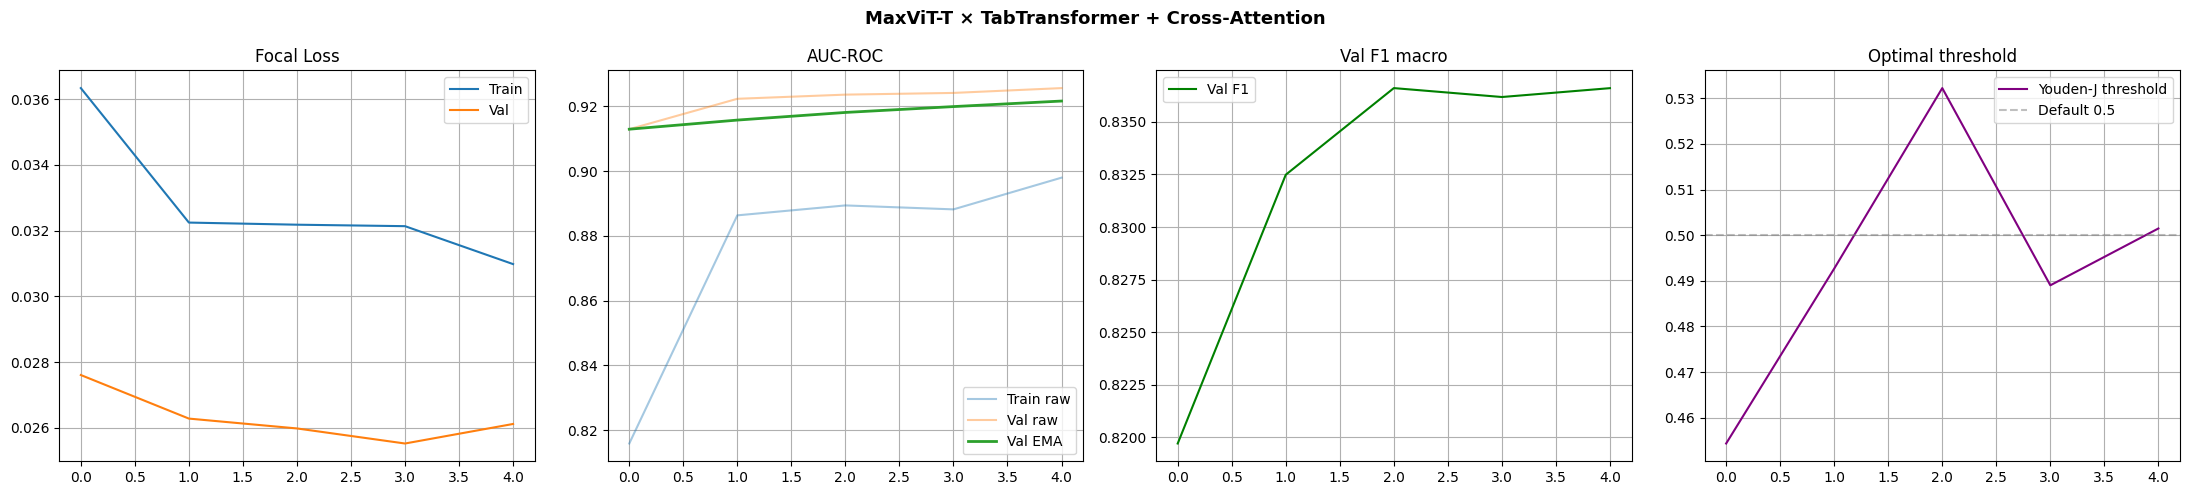

Saved: /kaggle/working/maxvit_outputs/training_curves.png


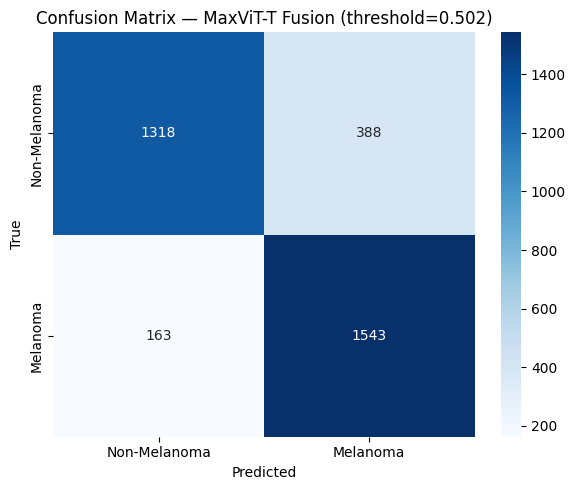

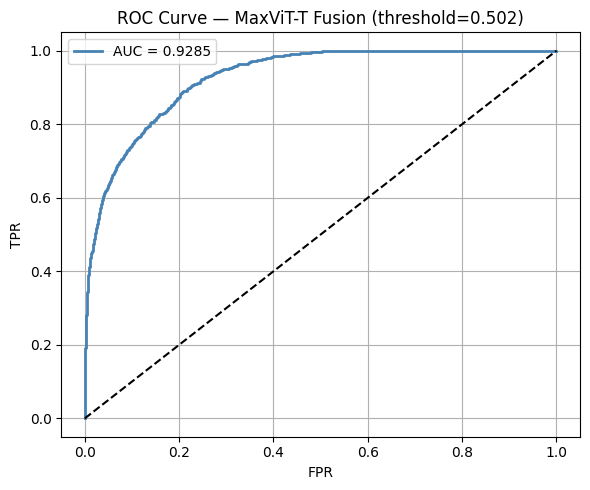

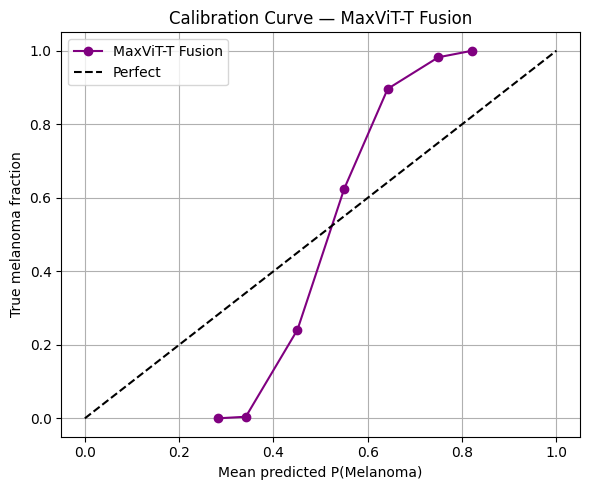


═════════════════════════════════════════════════════════════════
  XAI Suite — 6 Methods
  1. Grad-CAM / Grad-CAM++   2. Integrated Gradients   3. LIME
  4. Cross-Attention Maps    5. SHAP   6. PDP + ICE
  Samples: 3
═════════════════════════════════════════════════════════════════


  ── Sample 1/3  (Melanoma) ──
    [1] Grad-CAM / Grad-CAM++…


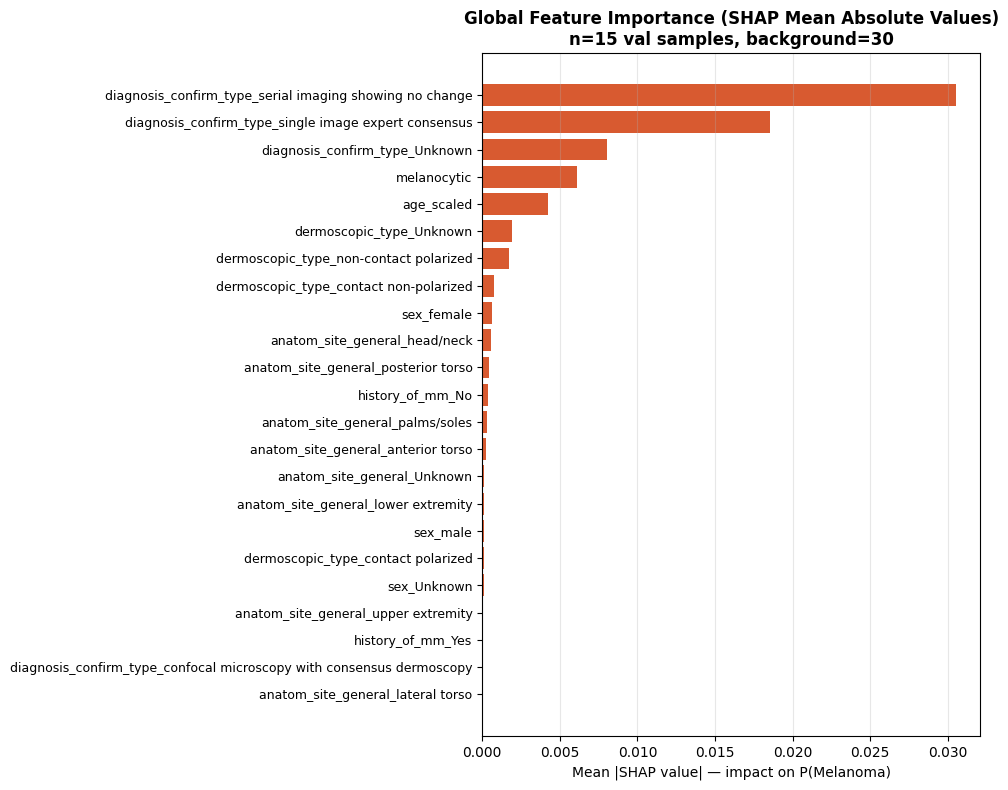

  ✔ /kaggle/working/maxvit_outputs/xai_5a_shap_bar.png


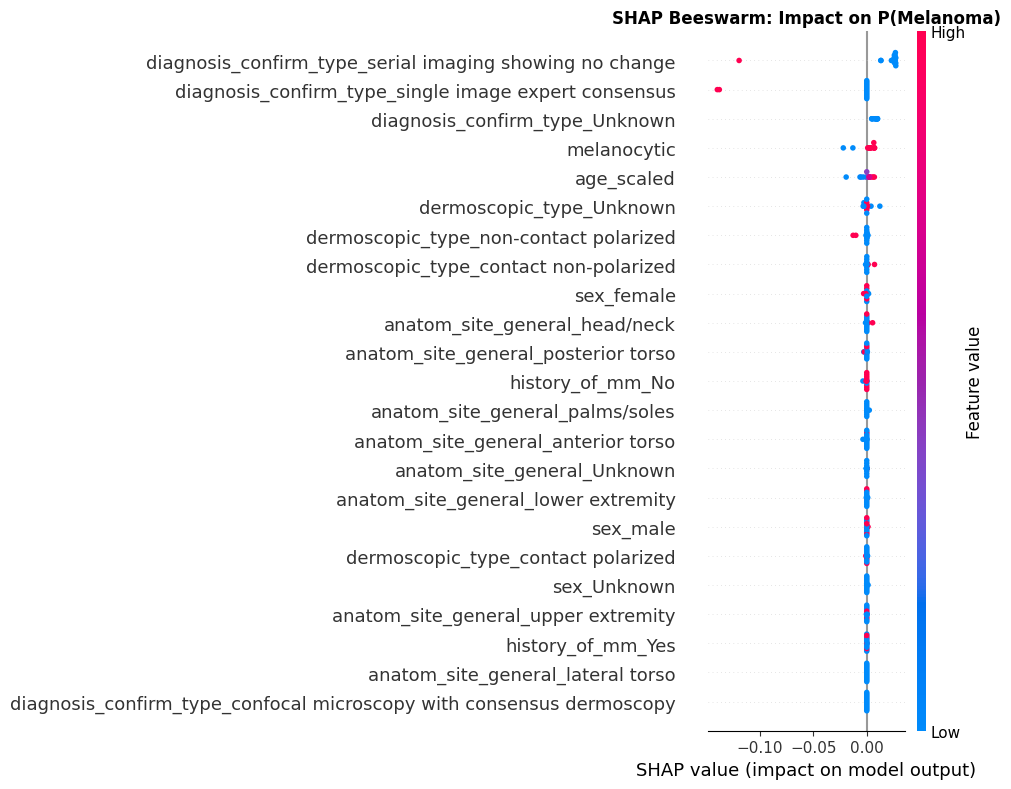

  ✔ /kaggle/working/maxvit_outputs/xai_5b_shap_beeswarm.png


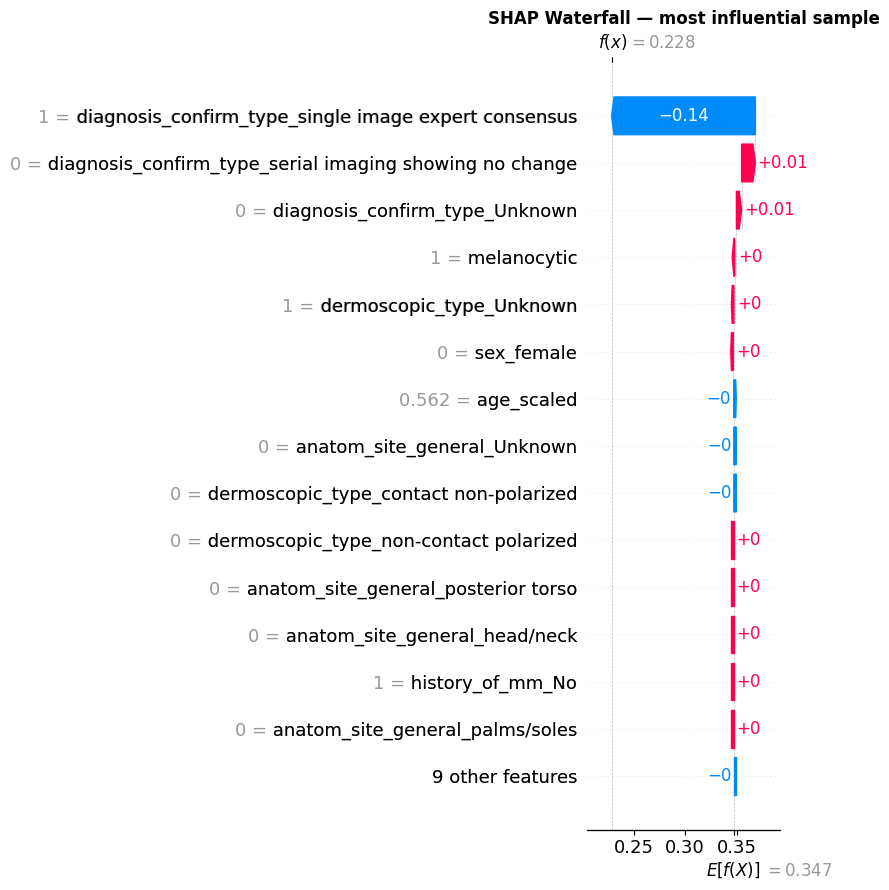

  ✔ /kaggle/working/maxvit_outputs/xai_5c_shap_waterfall.png

  ✔ SHAP importance CSV → /kaggle/working/maxvit_outputs/xai_shap_importance.csv
  Top 10:
                                                feature  mean_abs_shap
diagnosis_confirm_type_serial imaging showing no change       0.030545
   diagnosis_confirm_type_single image expert consensus       0.018536
                         diagnosis_confirm_type_Unknown       0.008070
                                            melanocytic       0.006080
                                             age_scaled       0.004206
                               dermoscopic_type_Unknown       0.001910
                 dermoscopic_type_non-contact polarized       0.001736
                 dermoscopic_type_contact non-polarized       0.000775
                                             sex_female       0.000612
                          anatom_site_general_head/neck       0.000560

    [6] PDP plots…

  Computing PDP plots…
  PDP features: ['diag

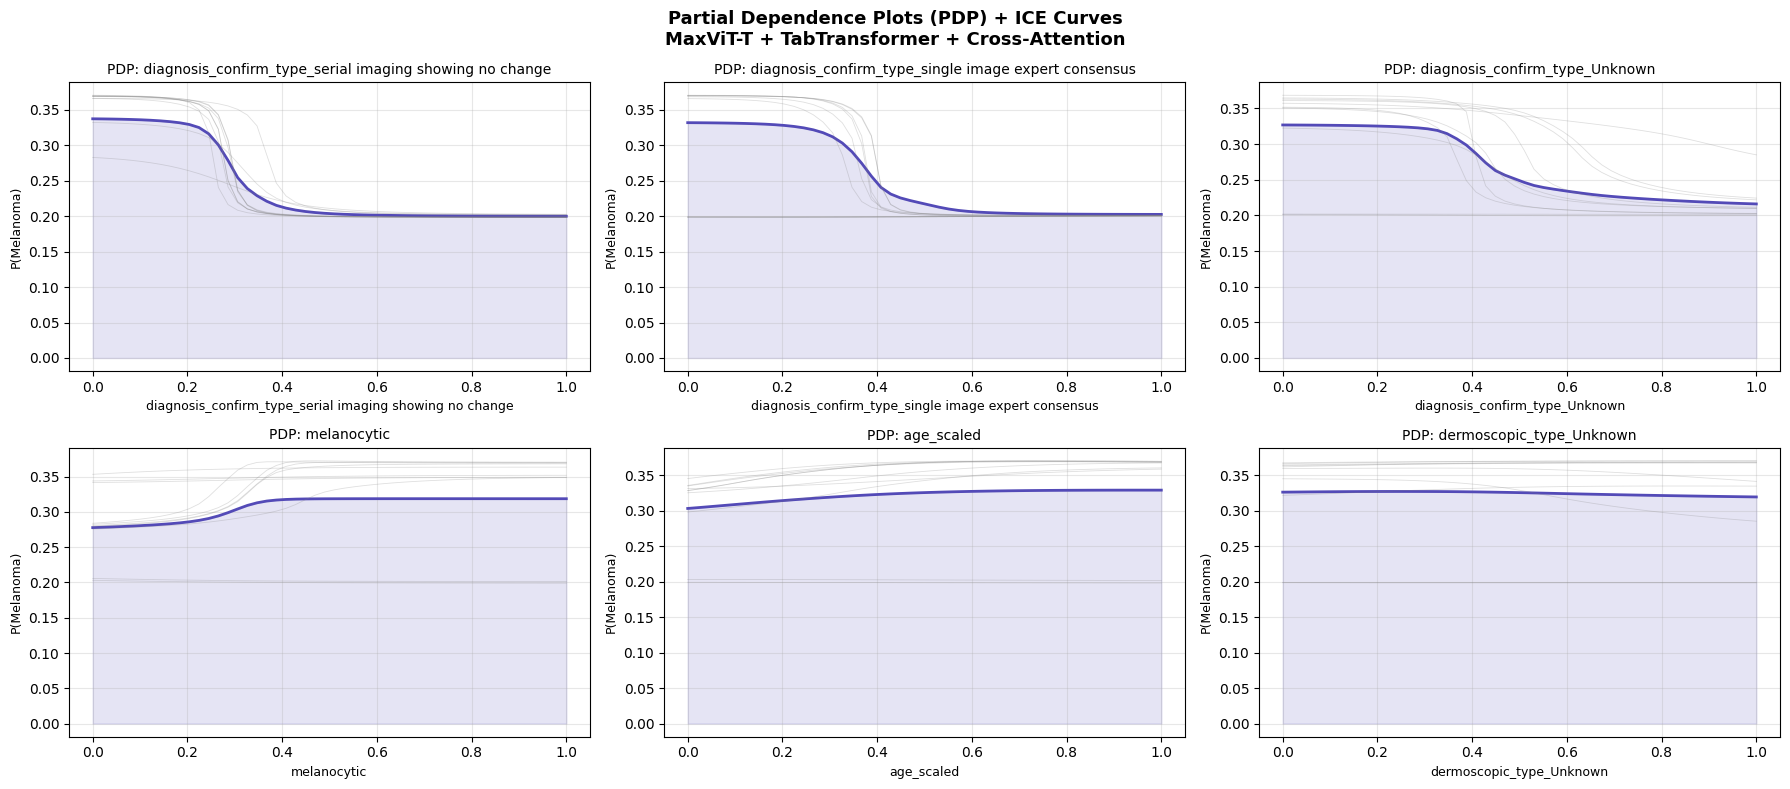

  ✔ /kaggle/working/maxvit_outputs/xai_6_pdp.png
  PDP complete for 6 features.

  ✅ All XAI outputs saved → /kaggle/working/maxvit_outputs/

  📄 val_df saved → /kaggle/working/maxvit_outputs/val_df.csv

All outputs saved to: /kaggle/working/maxvit_outputs/


In [4]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   ISIC-DICM-17K  —  MaxViT-T + TabTransformer + Cross-Attention            ║
║                   v2 FIXED  •  6 XAI Methods  •  Kaggle/Colab GPU          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Architecture:                                                               ║
║   • MaxViT-T (maxvit_tiny_tf_224.in1k) — hybrid CNN-Transformer backbone    ║
║     with Multi-Axis Self-Attention (window + grid) for long-range context   ║
║   • TabTransformer — per-feature embeddings + Transformer for metadata      ║
║   • Cross-Attention Fusion — bidirectional: meta queries image tokens       ║
║   • Classifier head — LayerNorm → Linear → GELU → Dropout → 2-class out    ║
║                                                                              ║
║  XAI methods implemented:                                                    ║
║   1. Grad-CAM / Grad-CAM++  — spatial heatmap on proj[0] Conv2d            ║
║   2. Integrated Gradients   — pixel + tabular attribution (Captum)          ║
║   3. LIME                   — superpixel-level image explanation            ║
║   4. Cross-Attention Maps   — which clinical feature attends where          ║
║   5. SHAP KernelExplainer   — global clinical feature importance            ║
║   6. PDP Plots              — how each metadata feature shifts P(Melanoma)  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Fixes vs v1:                                                                ║
║   • [CRITICAL] Optimizer param group: fixed nonsensical pos_emb expression  ║
║   • [CRITICAL] Backbone: features_only=True, index [-1] → (B,C,H,W)        ║
║   • [CRITICAL] Grad-CAM: target proj[0]; register_backward_hook (not full)  ║
║   • [CRITICAL] UNFREEZE epochs aligned to EPOCHS (2/4 for 5-epoch run)      ║
║   • [MODERATE] backbone.stages guard (hasattr) in freeze/unfreeze helpers   ║
║   • [MODERATE] Cross-attn assertion for attention shape validation          ║
║   • [MODERATE] UNFREEZE_EPOCH_2: scheduler.add_new_param_group now called   ║
║   • [QUALITY]  label smoothing uses CFG.LABEL_SMOOTH (was hardcoded 0.05)   ║
║   • [QUALITY]  SHAP/PDP mean_img uses proper ImageNet mean, not zeros       ║
║   • [QUALITY]  XAI model.train() before Grad-CAM backward, eval() after     ║
║   • [QUALITY]  TTA batched per-transform (not sample-by-sample)             ║
║   • Flow exactly mirrors EfficientNetV2-S notebook for fair comparison      ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, gc, re, math, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, f1_score)
from sklearn.calibration import calibration_curve
from sklearn.inspection import partial_dependence

from captum.attr import IntegratedGradients
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
import shap


# ── 1. Configuration ──────────────────────────────────────────────────────────
class CFG:
    # ── Paths ─────────────────────────────────────────────────────────────────
    CSV_PATH   = "/kaggle/input/datasets/janaahmedmohamed/final-preprocessed-data-csv/final_preprocessed_data.csv"
    IMAGES_DIR = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
    OUTPUT_DIR = "/kaggle/working/maxvit_outputs/"

    # ── Column names ──────────────────────────────────────────────────────────
    IMG_COL    = "image"
    TARGET_COL = "class"

    DROP_COLS  = [
        "image", "isic_id", "patient_id", "class",
        "diagnosis_confirm_type_histopathology",
        "anatom_site_general_oral/genital",
        "age_group_0-20", "age_group_21-40",
        "age_group_41-60", "age_group_61-85",
        "year",
    ]

    # ── Image ─────────────────────────────────────────────────────────────────
    IMG_SIZE   = 224          # MaxViT-T native resolution
    MEAN       = [0.485, 0.456, 0.406]
    STD        = [0.229, 0.224, 0.225]

    # ── Architecture ──────────────────────────────────────────────────────────
    D             = 128        # shared embedding dim
    NUM_HEADS     = 8
    FF_DIM        = 256
    NUM_CA_LAYERS = 2
    DROPOUT_TF    = 0.15
    TAB_DEPTH     = 2
    TAB_HEADS     = 4
    MAXVIT_MODEL  = "maxvit_tiny_tf_224.in1k"

    # ── Training ──────────────────────────────────────────────────────────────
    SEED          = 42
    EPOCHS        = 5
    BATCH_SIZE    = 16
    GRAD_ACCUM    = 2
    NUM_WORKERS   = 2
    PATIENCE      = 10
    LABEL_SMOOTH  = 0.10
    FOCAL_ALPHA   = 0.25
    FOCAL_GAMMA   = 2.0
    LR_BACKBONE   = 2e-5
    LR_HEAD       = 2e-4
    WEIGHT_DECAY  = 1e-4
    WARMUP_EPOCHS = 3
    # FIX #5: align unfreeze epochs to actual EPOCHS (was 10/20 with EPOCHS=5)
    UNFREEZE_EPOCH_1 = 2    # unfreeze stages 2-3 at epoch 2
    UNFREEZE_EPOCH_2 = 4    # unfreeze all stages at epoch 4
    EMA_ALPHA     = 0.3
    CUTMIX_PROB   = 0.30
    MIXUP_PROB    = 0.20
    CUTMIX_ALPHA  = 1.0
    MIXUP_ALPHA   = 0.4
    TTA_STEPS     = 5
    USE_KFOLD     = False
    N_FOLDS       = 5

    # ── XAI ───────────────────────────────────────────────────────────────────
    # FIX #15: reduce XAI_N_SAMPLES and LIME_N_SAMPLES for speed
    XAI_N_SAMPLES      = 3
    XAI_IG_STEPS       = 20
    LIME_N_SAMPLES     = 200
    LIME_N_SEGMENTS    = 60
    SHAP_BACKGROUND    = 30
    SHAP_NSAMPLES      = 50
    SHAP_EXPLAIN       = 15
    PDP_N_FEATURES     = 6
    PDP_GRID_POINTS    = 50

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
print(f"Device : {CFG.DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if CFG.DEVICE == 'cuda' else 'N/A'}")


# ── 2. Feature Validator ──────────────────────────────────────────────────────
def validate_features(df, meta_cols):
    print("\n── Feature validation ──")
    issues = []
    for c in meta_cols:
        if df[c].std() == 0:
            issues.append(f"DEAD COLUMN (zero variance): {c}")
    for c in meta_cols:
        r = abs(df[c].corr(df[CFG.TARGET_COL]))
        if r > 0.45:
            issues.append(f"LEAKAGE RISK (r={r:.3f} with class): {c}")
    if issues:
        for i in issues:
            print(f"  {i}")
        raise ValueError("Fix issues above — add column names to CFG.DROP_COLS.")
    sparse = [(c, (df[c] == 0).mean()) for c in meta_cols
              if (df[c] == 0).mean() > 0.99]
    if sparse:
        print("  Sparse features (>99% zeros) — keeping as missing-data signal:")
        for c, pct in sparse:
            print(f"    {c} ({pct*100:.1f}% zeros)")
    print(f"  Passed — {len(meta_cols)} clean features ready.\n")


# ── 3. EMA & Threshold helpers ────────────────────────────────────────────────
class EMAMetric:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.value = None

    def update(self, v):
        self.value = v if self.value is None \
            else self.alpha * v + (1 - self.alpha) * self.value
        return self.value


def find_optimal_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j        = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])


# ── 4. Temperature Scaling ────────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    """
    Learns a single scalar T on the validation set so that
    softmax(logits / T) produces calibrated probabilities.
    """
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature.clamp(min=0.05)

    def fit(self, model, loader, device, n_iter=100, lr=0.02):
        self.to(device)
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=n_iter)
        all_logits, all_labels = [], []
        model.eval()
        with torch.no_grad():
            for images, metas, labels in loader:
                logits = model(images.to(device), metas.to(device))
                all_logits.append(logits.cpu())
                all_labels.append(labels.cpu())
        logits_t = torch.cat(all_logits).to(device)
        labels_t = torch.cat(all_labels).to(device)

        def _closure():
            optimizer.zero_grad()
            loss = F.cross_entropy(self(logits_t), labels_t)
            loss.backward()
            return loss

        optimizer.step(_closure)
        print(f"  Temperature T = {self.temperature.item():.4f}")
        return self


# ── 5. Dataset ────────────────────────────────────────────────────────────────
class ISICDataset(Dataset):
    def __init__(self, df, images_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.meta_cols  = [c for c in df.columns if c not in CFG.DROP_COLS]
        self.meta_dim   = len(self.meta_cols)
        self.augment    = augment

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
                transforms.RandomGrayscale(p=0.1),
                transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
                transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ])

        self.tta_transforms = [
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomHorizontalFlip(p=1.0),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomVerticalFlip(p=1.0),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomRotation(degrees=(90, 90)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
            transforms.Compose([transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                                 transforms.RandomRotation(degrees=(270, 270)),
                                 transforms.ToTensor(), transforms.Normalize(CFG.MEAN, CFG.STD)]),
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = str(row[CFG.IMG_COL])
        img_path = os.path.join(self.images_dir, img_name)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing: {img_path}")
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        meta  = torch.tensor(row[self.meta_cols].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(int(row[CFG.TARGET_COL]), dtype=torch.long)
        return image, meta, label


def make_weighted_sampler(labels, epoch=0):
    class_counts  = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_w      = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_w).float(),
        num_samples=len(sample_w),
        replacement=True,
        generator=torch.Generator().manual_seed(CFG.SEED + epoch),
    )


# ── 6. Augmentation Mix ───────────────────────────────────────────────────────
def cutmix_batch(images, labels, alpha=1.0):
    B   = images.size(0)
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(B)
    W, H = images.size(3), images.size(2)
    cut_w, cut_h = int(W * np.sqrt(1 - lam)), int(H * np.sqrt(1 - lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = max(cx - cut_w // 2, 0), min(cx + cut_w // 2, W)
    y1, y2 = max(cy - cut_h // 2, 0), min(cy + cut_h // 2, H)
    images_m = images.clone()
    images_m[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1)) / (W * H)
    return images_m, labels, labels[idx], lam


def mixup_batch(images, labels, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0))
    return lam * images + (1 - lam) * images[idx], labels, labels[idx], lam


def apply_augmentation_mix(images, labels):
    rand = np.random.random()
    if rand < CFG.CUTMIX_PROB:
        images, la, lb, lam = cutmix_batch(images, labels, CFG.CUTMIX_ALPHA)
        return images, la, lb, lam, True
    elif rand < CFG.CUTMIX_PROB + CFG.MIXUP_PROB:
        images, la, lb, lam = mixup_batch(images, labels, CFG.MIXUP_ALPHA)
        return images, la, lb, lam, True
    else:
        return images, labels, labels, 1.0, False


# ── 7. Model Components ───────────────────────────────────────────────────────

class MaxViTEncoder(nn.Module):
    """
    MaxViT-T backbone for spatial token extraction.
    MaxViT uses alternating local-window and global-grid attention (Multi-Axis
    Self-Attention), giving it the best of CNN efficiency and ViT global context.

    FIX #2: Use features_only=True and index [-1] to get the last stage's
    spatial feature map as (B, C, H, W). The old global_pool="" approach
    returned a 2D tensor on maxvit_tiny_tf_224.in1k and the dim==4 branch
    was never reached.
    """
    def __init__(self, out_dim=128, dropout=0.15):
        super().__init__()
        # FIX #2: features_only=True → returns list of (B, C, H, W) per stage
        self.backbone = timm.create_model(
            CFG.MAXVIT_MODEL, pretrained=True, features_only=True
        )
        self._features  = None
        self._gradients = None

        # Discover feature map dimensions from last stage output
        with torch.no_grad():
            dummy = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
            feats = self.backbone(dummy)[-1]   # last stage → (B, C, H, W)
            self.feat_dim = feats.shape[1]
            self.feat_h   = feats.shape[2]
            self.feat_w   = feats.shape[3]
            print(f"  MaxViT-T feature map: "
                  f"{self.feat_dim}×{self.feat_h}×{self.feat_w} "
                  f"→ {self.feat_h * self.feat_w} spatial tokens")

        # Project to shared dim D — proj[0] is the Conv2d targeted by Grad-CAM
        self.proj = nn.Sequential(
            nn.Conv2d(self.feat_dim, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim), nn.GELU(), nn.Dropout2d(dropout),
        )
        n_patches    = self.feat_h * self.feat_w
        self.pos_emb = nn.Parameter(torch.zeros(1, n_patches, out_dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, out_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Freeze early stages by default
        self._freeze_stages(2)

    def _freeze_stages(self, n_stages):
        """Freeze first n_stages of MaxViT backbone. FIX #6: guard with hasattr."""
        stages = list(self.backbone.stages.children()) if hasattr(self.backbone, "stages") else []
        if not stages:
            print("  WARNING: Could not find backbone.stages — no stage freezing applied")
        for i, stage in enumerate(stages):
            if i < n_stages:
                for param in stage.parameters():
                    param.requires_grad = False
        # Also freeze stem if present
        if hasattr(self.backbone, "stem"):
            for param in self.backbone.stem.parameters():
                param.requires_grad = False
        trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f"  Frozen first {n_stages} stages | trainable backbone params: {trainable:,}")

    def unfreeze_stages(self, from_stage, to_stage):
        """Progressively unfreeze MaxViT stages. FIX #6: guard with hasattr."""
        stages = list(self.backbone.stages.children()) if hasattr(self.backbone, "stages") else []
        if not stages:
            print("  WARNING: Could not find backbone.stages — unfreeze skipped")
            return
        for i, stage in enumerate(stages):
            if from_stage <= i < to_stage:
                for param in stage.parameters():
                    param.requires_grad = True
        trainable = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        print(f"  🔓 Unfroze stages {from_stage}–{to_stage-1} | trainable: {trainable:,}")

    def get_newly_unfrozen_params(self, from_stage, to_stage):
        """Return newly unfrozen parameters. FIX #6: guard with hasattr."""
        stages = list(self.backbone.stages.children()) if hasattr(self.backbone, "stages") else []
        params = []
        for i, stage in enumerate(stages):
            if from_stage <= i < to_stage:
                params += [p for p in stage.parameters() if p.requires_grad]
        return params

    def forward(self, x):
        # FIX #2: call backbone → list of feature maps, take last → (B, C, H, W)
        feats  = self.backbone(x)[-1]       # (B, C, H, W)
        tokens = self.proj(feats)           # (B, D, H, W)
        B, D, H, W = tokens.shape
        tokens = tokens.flatten(2).transpose(1, 2)   # (B, H*W, D)
        tokens = tokens + self.pos_emb
        cls    = self.cls_token.expand(B, -1, -1)
        return torch.cat([cls, tokens], dim=1)        # (B, 1+H*W, D)


class TabTransformerEncoder(nn.Module):
    """
    Per-feature linear projection + positional embedding + Transformer encoder.
    Each clinical feature becomes one token. CLS token aggregates metadata.
    """
    def __init__(self, num_features, embed_dim=128, depth=2,
                 num_heads=4, ff_dim=256, dropout=0.15):
        super().__init__()
        self.num_features = num_features
        self.feature_embeddings = nn.ModuleList([
            nn.Sequential(nn.Linear(1, embed_dim), nn.LayerNorm(embed_dim))
            for _ in range(num_features)
        ])
        self.pos_emb   = nn.Parameter(torch.zeros(1, num_features, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.pos_emb,   std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm        = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B      = x.size(0)
        tokens = torch.stack([
            self.feature_embeddings[i](x[:, i:i+1])
            for i in range(self.num_features)
        ], dim=1)
        tokens = tokens + self.pos_emb
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.transformer(tokens)
        return self.norm(tokens)


class CrossAttentionBlock(nn.Module):
    """
    Bidirectional cross-attention fusion:
      • Image tokens self-attend  (local spatial context)
      • Meta tokens attend image  (clinical features query visual regions)
    Per-head attention weights stored for XAI cross-attention maps.
    """
    def __init__(self, dim, num_heads, ff_dim, dropout=0.15):
        super().__init__()
        self.meta_to_img = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.img_self_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True,
        )
        self.ffn_meta = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self.ffn_img  = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self.norm_img  = nn.LayerNorm(dim)
        self.norm_meta = nn.LayerNorm(dim)

    def forward(self, img_tokens, meta_tokens, need_attn_weights=False):
        # Image self-attention
        img_sa, _ = self.img_self_attn(
            query=self.norm_img(img_tokens),
            key=img_tokens, value=img_tokens, need_weights=False,
        )
        img_tokens  = img_tokens + img_sa
        img_tokens  = img_tokens + self.ffn_img(img_tokens)

        # Cross-attention: meta tokens (query) attend to image tokens (key/value)
        # average_attn_weights=False → shape (B, num_heads, n_meta, n_img)
        meta_ca, attn_weights = self.meta_to_img(
            query=self.norm_meta(meta_tokens),
            key=img_tokens, value=img_tokens,
            need_weights=True,
            average_attn_weights=False,
        )
        meta_tokens = meta_tokens + meta_ca
        meta_tokens = meta_tokens + self.ffn_meta(meta_tokens)

        return img_tokens, meta_tokens, attn_weights   # (B, H, n_meta, n_img)


class MaxViTFusionModel(nn.Module):
    """
    Full multimodal model:
      MaxViT-T → spatial image tokens
      TabTransformer → clinical metadata tokens
      N × CrossAttentionBlock → fused representations
      Classifier → 2-class output (Non-Melanoma / Melanoma)
    """
    def __init__(self, meta_dim):
        super().__init__()
        D = CFG.D
        self.img_encoder  = MaxViTEncoder(out_dim=D, dropout=CFG.DROPOUT_TF)
        self.meta_encoder = TabTransformerEncoder(
            num_features=meta_dim, embed_dim=D, depth=CFG.TAB_DEPTH,
            num_heads=CFG.TAB_HEADS, ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF,
        )
        self.ca_layers = nn.ModuleList([
            CrossAttentionBlock(dim=D, num_heads=CFG.NUM_HEADS,
                                ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF)
            for _ in range(CFG.NUM_CA_LAYERS)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(D * 2), nn.Linear(D * 2, 256),
            nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 2),
        )
        self._ca_weights_per_layer = []
        total_p     = sum(p.numel() for p in self.parameters())
        trainable_p = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Total params    : {total_p:,}")
        print(f"  Trainable params: {trainable_p:,}")

    def forward(self, image, meta):
        img_tokens  = self.img_encoder(image)
        meta_tokens = self.meta_encoder(meta)
        self._ca_weights_per_layer = []
        for ca in self.ca_layers:
            img_tokens, meta_tokens, attn = ca(img_tokens, meta_tokens,
                                               need_attn_weights=True)
            self._ca_weights_per_layer.append(attn.detach())
        img_cls  = img_tokens[:, 0, :]
        meta_cls = meta_tokens[:, 0, :]
        fused    = torch.cat([img_cls, meta_cls], dim=1)
        return self.classifier(fused)

    def get_cross_attention(self, layer=-1):
        return self._ca_weights_per_layer[layer]   # (B, H, n_meta, n_img)

    def unfreeze_backbone_stages(self, from_stage, to_stage):
        self.img_encoder.unfreeze_stages(from_stage, to_stage)

    def get_newly_unfrozen_params(self, from_stage, to_stage):
        return self.img_encoder.get_newly_unfrozen_params(from_stage, to_stage)


# ── 8. Loss Functions ─────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.10):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n  = logits.size(1)
        lp = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            s = torch.full_like(lp, self.smoothing / (n - 1))
            s.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        ce   = -(s * lp).sum(dim=1)
        pt   = torch.exp(-ce)
        return (self.alpha * (1 - pt) ** self.gamma * ce).mean()


class MixLoss(nn.Module):
    # FIX #12: pass CFG.LABEL_SMOOTH explicitly (was hardcoded 0.05)
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=None):
        super().__init__()
        smoothing = smoothing if smoothing is not None else CFG.LABEL_SMOOTH
        self.focal = FocalLoss(alpha, gamma, smoothing)

    def forward(self, logits, targets_a, targets_b=None, lam=1.0):
        if targets_b is None or lam == 1.0:
            return self.focal(logits, targets_a)
        return lam * self.focal(logits, targets_a) + (1 - lam) * self.focal(logits, targets_b)


# ── 9. LR Scheduler ───────────────────────────────────────────────────────────
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.opt           = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        self.base_lrs      = [pg["lr"] for pg in optimizer.param_groups]

    def add_new_param_group(self, lr):
        self.base_lrs.append(lr)

    def step(self, epoch):
        e = epoch - 1
        if e < self.warmup_epochs:
            scale = max(0.01, (e + 1) / self.warmup_epochs)
        else:
            progress  = (e - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            min_scale = self.min_lr / max(self.base_lrs)
            scale     = max(0.5 * (1 + math.cos(math.pi * progress)), min_scale)
        for pg, base in zip(self.opt.param_groups, self.base_lrs):
            pg["lr"] = base * scale

    def get_lr(self):
        return [pg["lr"] for pg in self.opt.param_groups]


# ── 10. Train / Eval Loops ────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler_amp, device):
    model.train()
    total_loss = 0
    all_labels, all_probs = [], []
    optimizer.zero_grad()

    for step, (images, metas, labels) in enumerate(tqdm(loader, desc="  Train", leave=False)):
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        images, la, lb, lam, use_mix = apply_augmentation_mix(images, labels)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            loss   = criterion(logits, la, lb if use_mix else None, lam) / CFG.GRAD_ACCUM

        scaler_amp.scale(loss).backward()
        if (step + 1) % CFG.GRAD_ACCUM == 0:
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()

        total_loss += loss.item() * CFG.GRAD_ACCUM * images.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().float().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(la.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5, temperature_scaler=None):
    model.eval()
    total_loss = 0
    all_labels, all_probs = [], []

    for images, metas, labels in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            if temperature_scaler is not None:
                logits = temperature_scaler(logits)
            loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        probs  = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    labels_np = np.array(all_labels)
    probs_np  = np.array(all_probs)
    preds_np  = (probs_np >= threshold).astype(int)
    auc       = roc_auc_score(labels_np, probs_np)
    f1        = f1_score(labels_np, preds_np, average="macro")
    return total_loss / len(loader.dataset), auc, f1, labels_np, preds_np, probs_np


# FIX #11: TTA batched per-transform, not sample-by-sample
@torch.no_grad()
def evaluate_with_tta(model, dataset, device, threshold=0.5,
                      temperature_scaler=None):
    """
    Test-Time Augmentation: iterate over each TTA transform, run a full
    dataloader pass per transform, then average the probabilities.
    This is O(n_tta × n_batches) instead of the old O(n_samples × n_tta)
    single-sample loop.
    """
    model.eval()
    all_labels = []
    all_probs  = []   # will be list of per-transform prob arrays
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)
    print("  Running TTA inference…")

    for tta_idx, tta_tf in enumerate(dataset.tta_transforms):
        orig_tf = dataset.transform
        dataset.transform = tta_tf
        tta_probs = []
        for images, metas, labels in tqdm(
                loader, desc=f"  TTA {tta_idx+1}/{len(dataset.tta_transforms)}", leave=False):
            images = images.to(device, non_blocking=True)
            metas  = metas.to(device,  non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                logits = model(images, metas)
                if temperature_scaler is not None:
                    logits = temperature_scaler(logits)
            probs = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
            tta_probs.extend(probs)
            if tta_idx == 0:
                all_labels.extend(labels.numpy())
        all_probs.append(np.array(tta_probs))
        dataset.transform = orig_tf

    avg_probs = np.mean(all_probs, axis=0)
    labels_np = np.array(all_labels)
    preds_np  = (avg_probs >= threshold).astype(int)
    auc       = roc_auc_score(labels_np, avg_probs)
    f1        = f1_score(labels_np, preds_np, average="macro")
    print(f"  TTA AUC: {auc:.4f}  F1: {f1:.4f}")
    return auc, f1, labels_np, preds_np, avg_probs


# ── 11. Plot Helpers ──────────────────────────────────────────────────────────
def plot_training_curves(history, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history["train_auc"],    label="Train raw", alpha=0.4)
    axes[1].plot(history["val_auc"],      label="Val raw",   alpha=0.4)
    axes[1].plot(history["val_auc_ema"],  label="Val EMA",   lw=2)
    axes[1].set_title("AUC-ROC"); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history["val_f1"], color="green", label="Val F1")
    axes[2].set_title("Val F1 macro"); axes[2].legend(); axes[2].grid(True)
    axes[3].plot(history["threshold"], color="purple", label="Youden-J threshold")
    axes[3].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default 0.5")
    axes[3].set_title("Optimal threshold"); axes[3].legend(); axes[3].grid(True)
    plt.suptitle(f"MaxViT-T × TabTransformer + Cross-Attention"
                 f"{' | Fold '+str(fold) if fold else ''}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(CFG.OUTPUT_DIR, f"training_curves{tag}.png")
    plt.savefig(path, dpi=150); plt.show(); plt.close()
    print(f"Saved: {path}")


def plot_confusion_matrix(labels, preds, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Melanoma", "Melanoma"],
                yticklabels=["Non-Melanoma", "Melanoma"], ax=ax)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    ax.set_title(f"Confusion Matrix — MaxViT-T Fusion (threshold={threshold:.3f})")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"confusion_matrix{tag}.png"), dpi=150)
    plt.show(); plt.close()


def plot_roc_curve(labels, probs, auc_score, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fpr, tpr, _ = roc_curve(labels, probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_score:.4f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curve — MaxViT-T Fusion (threshold={threshold:.3f})")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"roc_curve{tag}.png"), dpi=150)
    plt.show(); plt.close()


def plot_calibration_curve(labels, probs, fold=None):
    tag = f"_fold{fold}" if fold else ""
    prob_true, prob_pred = calibration_curve(labels, probs, n_bins=10)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o", color="purple", label="MaxViT-T Fusion")
    ax.plot([0, 1], [0, 1], "k--", label="Perfect")
    ax.set_xlabel("Mean predicted P(Melanoma)")
    ax.set_ylabel("True melanoma fraction")
    ax.set_title("Calibration Curve — MaxViT-T Fusion")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"calibration_curve{tag}.png"), dpi=150)
    plt.show(); plt.close()


# ═══════════════════════════════════════════════════════════════════════════════
#  XAI SECTION — 6 Methods
# ═══════════════════════════════════════════════════════════════════════════════

_XAI_TF = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CFG.MEAN, CFG.STD),
])

def _norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

def _resize_map(arr2d, size):
    pil = Image.fromarray((_norm01(arr2d) * 255).astype(np.uint8))
    return np.array(pil.resize((size, size), Image.BILINEAR)) / 255.0

def _overlay(rgb, heatmap, alpha=0.5):
    colored = mpl_cm.get_cmap("jet")(heatmap)[..., :3]
    return np.clip((1 - alpha) * rgb + alpha * colored, 0, 1)

def _save(fig, name):
    path = os.path.join(CFG.OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  ✔ {path}")

def _xai_load(img_name_or_path, meta_series):
    raw  = str(img_name_or_path).split("/")[-1]
    m    = re.search(r"(\d{7})", raw)
    name = f"ISIC_{m.group(1)}.jpg" if m else raw
    path = os.path.join(CFG.IMAGES_DIR, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"XAI image not found: {path}")
    img = Image.open(path).convert("RGB")
    it  = _XAI_TF(img).unsqueeze(0).to(CFG.DEVICE)
    mt  = torch.tensor(meta_series.values.astype(np.float32),
                       dtype=torch.float32).unsqueeze(0).to(CFG.DEVICE)
    rgb = it.squeeze().cpu().permute(1, 2, 0).numpy() * np.array(CFG.STD) + np.array(CFG.MEAN)
    return it, mt, np.clip(rgb, 0, 1), path


# ── XAI Method 1 & 2: Grad-CAM and Grad-CAM++ ────────────────────────────────
class _GradCAMEngine:
    """
    FIX #3: Target proj[0] (the 1×1 Conv2d projection) instead of searching
    for 'last Conv2d in backbone' — MaxViT's backbone is transformer-based
    and its last Conv2d is deep in the stem, not the final feature layer.
    proj[0] is always (B, D, H, W) and model-agnostic.

    FIX #3b: Use register_backward_hook (not register_full_backward_hook)
    for nn.Conv2d targets — the full_backward_hook signature differs.

    FIX #10: Set model.train() before backward for correct BN/Dropout,
    then model.eval() after.
    """
    def __init__(self, model, plus_plus=False):
        self.model     = model
        self.plus_plus = plus_plus
        self._acts = self._grads = None
        # FIX #3: hook on proj[0] — always the 1x1 Conv2d projection
        target_layer = model.img_encoder.proj[0]
        self._fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "_acts", o.detach()))
        # FIX #3b: register_backward_hook (not full)
        self._bh = target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, "_grads", go[0].detach()))

    def remove(self):
        self._fh.remove(); self._bh.remove()

    def __call__(self, img_t, meta_t, class_idx=1):
        # FIX #10: train mode for gradient flow
        self.model.train()
        self.model.zero_grad()
        logits = self.model(img_t, meta_t)
        logits[0, class_idx].backward()
        g, a = self._grads, self._acts
        if g is None or a is None:
            raise RuntimeError("Grad-CAM hooks did not fire — check target layer.")
        if self.plus_plus:
            g2, g3 = g ** 2, g ** 3
            denom  = 2 * g2 + g3 * a.sum(dim=(2, 3), keepdim=True) + 1e-8
            w      = (g2 / denom * F.relu(g)).sum(dim=(2, 3), keepdim=True)
        else:
            w = g.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * a).sum(dim=1).squeeze())
        # FIX #10: restore eval mode
        self.model.eval()
        return _norm01(cam.cpu().numpy())


def xai_gradcam(model, img_t, meta_t, rgb, save_tag="", class_idx=1):
    """XAI Method 1 & 2: Grad-CAM and Grad-CAM++ side-by-side."""
    S = rgb.shape[0]
    gc_eng = _GradCAMEngine(model, plus_plus=False)
    gc_map = gc_eng(img_t.clone(), meta_t.clone(), class_idx)
    gc_eng.remove()
    pp_eng = _GradCAMEngine(model, plus_plus=True)
    pp_map = pp_eng(img_t.clone(), meta_t.clone(), class_idx)
    pp_eng.remove()

    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb);                                             axes[0].set_title("Original image")
    axes[1].imshow(_overlay(rgb, _resize_map(gc_map, S)));           axes[1].set_title("Grad-CAM")
    axes[2].imshow(_overlay(rgb, _resize_map(pp_map, S)));           axes[2].set_title("Grad-CAM++")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"Grad-CAM family  |  P(Melanoma) = {prob:.3f}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_1_gradcam{save_tag}.png")
    return gc_map, pp_map


# ── XAI Method 3: Integrated Gradients ───────────────────────────────────────
def xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols,
                              save_tag="", class_idx=1):
    """
    XAI Method 3: Integrated Gradients via Captum.
    Computes pixel-level attributions for the image and
    per-feature attributions for clinical metadata.
    """
    model.eval()
    if CFG.DEVICE == "cuda":
        torch.cuda.empty_cache()
        gc.collect()

    ig_eng = IntegratedGradients(model)
    model.zero_grad()
    attr, delta = ig_eng.attribute(
        inputs=(img_t, meta_t),
        baselines=(torch.zeros_like(img_t), torch.zeros_like(meta_t)),
        target=class_idx,
        n_steps=CFG.XAI_IG_STEPS,
        internal_batch_size=4,
        return_convergence_delta=True,
    )
    img_map  = _norm01(np.abs(attr[0].squeeze().permute(1, 2, 0).cpu().numpy()).sum(axis=-1))
    tab_attr = attr[1].squeeze().detach().cpu().numpy()
    n_feat   = len(meta_cols)
    top_k    = min(20, n_feat)
    order    = np.argsort(np.abs(tab_attr))[::-1][:top_k]
    vals     = tab_attr[order][::-1]
    names    = [meta_cols[i] for i in order][::-1]
    colors   = ["#d6604d" if v > 0 else "#4393c3" for v in vals]

    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()

    S   = rgb.shape[0]
    fig = plt.figure(figsize=(18, 6))
    gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.4])
    ax0, ax1, ax2 = [fig.add_subplot(gs[i]) for i in range(3)]
    ax0.imshow(rgb); ax0.axis("off"); ax0.set_title("Original image")
    ax1.imshow(_overlay(rgb, _resize_map(img_map, S))); ax1.axis("off")
    ax1.set_title(f"IG — image (Δ={delta.item():.3f}, steps={CFG.XAI_IG_STEPS})")
    ax2.barh(range(top_k), vals, color=colors)
    ax2.set_yticks(range(top_k)); ax2.set_yticklabels(names, fontsize=8)
    ax2.axvline(0, color="black", lw=0.8)
    ax2.set_title("IG — tabular\n(red=↑ melanoma, blue=↓ melanoma)")
    ax2.grid(axis="x", alpha=0.3)
    fig.suptitle(f"Integrated Gradients (multimodal)  |  P(Melanoma) = {prob:.3f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_2_ig{save_tag}.png")
    return img_map, tab_attr


# ── XAI Method 4: LIME ────────────────────────────────────────────────────────
def xai_lime(model, img_path, meta_t, rgb, meta_cols,
             save_tag="", class_idx=1):
    """
    XAI Method 4: LIME superpixel-level image explanation.
    Perturbs superpixels, fits a local linear model, ranks which
    regions push P(Melanoma) up or down.
    """
    def _predict_fn(images_np):
        """Batch-predict from HWC uint8 numpy arrays (LIME's format)."""
        preds = []
        batch_size = 8
        mean_t = torch.tensor(CFG.MEAN).view(3, 1, 1)
        std_t  = torch.tensor(CFG.STD).view(3, 1, 1)
        for i in range(0, len(images_np), batch_size):
            batch = images_np[i:i + batch_size]
            tensors = []
            for img_np in batch:
                t = transforms.ToTensor()(Image.fromarray(img_np.astype(np.uint8)))
                t = transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE))(t)
                t = (t - mean_t) / std_t
                tensors.append(t)
            img_batch  = torch.stack(tensors).to(CFG.DEVICE)
            meta_batch = meta_t.expand(len(tensors), -1)
            with torch.no_grad():
                logits = model(img_batch, meta_batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds.append(probs)
        return np.vstack(preds)

    rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    explainer = lime_image.LimeImageExplainer()
    segmenter = SegmentationAlgorithm("slic", n_segments=CFG.LIME_N_SEGMENTS,
                                       compactness=10, sigma=1)
    explanation = explainer.explain_instance(
        rgb_uint8, _predict_fn,
        top_labels=2, hide_color=0,
        num_samples=CFG.LIME_N_SAMPLES,
        segmentation_fn=segmenter,
        random_seed=CFG.SEED,
    )

    img_pos, mask_pos = explanation.get_image_and_mask(
        class_idx, positive_only=True, num_features=10, hide_rest=False)
    img_neg, mask_neg = explanation.get_image_and_mask(
        class_idx, positive_only=False, num_features=10, hide_rest=False)

    seg          = explanation.segments
    weights_dict = dict(explanation.local_exp[class_idx])
    heatmap = np.zeros(seg.shape, dtype=np.float32)
    for seg_id, weight in weights_dict.items():
        heatmap[seg == seg_id] = weight
    norm_heatmap = _norm01(heatmap)

    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(
            _XAI_TF(Image.fromarray(rgb_uint8)).unsqueeze(0).to(CFG.DEVICE), meta_t
        ), dim=1)[0, class_idx].item()

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(rgb_uint8);  axes[0].set_title("Original image");                     axes[0].axis("off")
    axes[1].imshow(img_pos);    axes[1].set_title("LIME — positive regions\n(supports melanoma)"); axes[1].axis("off")
    axes[2].imshow(img_neg);    axes[2].set_title("LIME — pos + neg\n(green=for, red=against)");   axes[2].axis("off")
    axes[3].imshow(_overlay(rgb, norm_heatmap, alpha=0.6))
    axes[3].set_title("LIME superpixel weight overlay"); axes[3].axis("off")
    fig.suptitle(f"LIME  |  P(Melanoma) = {prob:.3f}  |  "
                 f"n_seg={CFG.LIME_N_SEGMENTS}  n_samples={CFG.LIME_N_SAMPLES}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_3_lime{save_tag}.png")
    return explanation


# ── XAI Method 5: Cross-Attention Maps ───────────────────────────────────────
def xai_cross_attention(model, img_t, meta_t, rgb, meta_cols,
                         feat_h, feat_w, save_tag=""):
    """
    XAI Method 5: Cross-Attention Maps.
    Shows which spatial image region each clinical metadata feature attends to.
    Aggregated over both CA layers and all heads.

    FIX #7: Added assertion to verify attention shape matches expected dims
    before reshape, preventing silent wrong-shape errors.
    """
    model.eval()
    with torch.no_grad():
        _ = model(img_t, meta_t)

    # Get last CA layer attention: shape (1, n_heads, n_meta+1, n_img+1)
    attn     = model.get_cross_attention(layer=-1)   # (B=1, H, n_meta+1, n_img+1)
    attn     = attn[0]                               # (H, n_meta+1, n_img+1)
    attn_avg = attn.mean(dim=0).cpu().float().numpy()  # (n_meta+1, n_img+1)

    n_meta    = len(meta_cols)
    n_patches = feat_h * feat_w

    # Slice: meta features [1:n_meta+1] attending to image patches [1:n_patches+1]
    ca_meta_to_img = attn_avg[1:n_meta + 1, 1:n_patches + 1]  # (n_meta, n_patches)

    # FIX #7: assertion to catch shape mismatch before reshape
    assert ca_meta_to_img.shape == (n_meta, n_patches), (
        f"Attention shape mismatch: got {ca_meta_to_img.shape}, "
        f"expected ({n_meta}, {n_patches}). "
        f"Full attn_avg shape: {attn_avg.shape}"
    )

    feature_attn = ca_meta_to_img.mean(axis=1)   # (n_meta,)
    feature_attn = feature_attn / (feature_attn.max() + 1e-8)

    spatial_attn = ca_meta_to_img.mean(axis=0)    # (n_patches,)
    spatial      = spatial_attn.reshape(feat_h, feat_w)
    spatial_up   = _resize_map(spatial, rgb.shape[0])

    # ── Plot ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    n_show = min(n_meta, 25)
    order  = np.argsort(feature_attn)[::-1][:n_show]
    vals   = feature_attn[order][::-1]
    names  = [meta_cols[i] for i in order][::-1]
    cmap   = plt.cm.RdYlGn(vals / (vals.max() + 1e-8))
    axes[0].barh(range(n_show), vals, color=cmap)
    axes[0].set_yticks(range(n_show)); axes[0].set_yticklabels(names, fontsize=7)
    axes[0].set_xlabel("Normalised cross-attention weight")
    axes[0].set_title("Clinical feature → image attention\n(which feature attends most?)")
    axes[0].grid(axis="x", alpha=0.3)

    im = axes[1].imshow(spatial, cmap="hot", aspect="auto")
    axes[1].set_title(f"Spatial attention heatmap\n({feat_h}×{feat_w} patch grid)")
    plt.colorbar(im, ax=axes[1], fraction=0.046)
    axes[1].axis("off")

    axes[2].imshow(_overlay(rgb, spatial_up, alpha=0.55))
    axes[2].set_title("Cross-attention overlay\n(where do clinical features look?)")
    axes[2].axis("off")

    # Head diversity inset
    head_var = attn.cpu().numpy()[:, 1:n_meta+1, 1:n_patches+1].var(axis=0).mean(axis=1)
    axes[0].twinx().plot(head_var / (head_var.max() + 1e-8), range(n_show),
                         color="navy", alpha=0.4, linewidth=1.2, label="Head variance")

    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, 1].item()

    fig.suptitle(f"Cross-Attention Maps  |  P(Melanoma) = {prob:.3f}  |  "
                 f"Last CA layer  |  Avg over {attn.shape[0]} heads",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_4_cross_attention{save_tag}.png")
    return feature_attn, spatial_up


# ── XAI Method 6: SHAP KernelExplainer ───────────────────────────────────────
def run_shap(model, val_df, meta_cols, rep_img_t, save_tag=""):
    """
    XAI Method 6: SHAP KernelExplainer for global clinical feature importance.
    FIX #13: Use proper ImageNet-mean image instead of black zeros image,
    so SHAP attributions reflect realistic baseline behaviour.
    """
    print(f"\n{'═'*65}")
    print("  SHAP — Global Clinical Feature Importance")
    print(f"{'═'*65}")

    model.eval()

    # FIX #13: use actual normalized mean image, not zeros
    mean_img_np = np.array(CFG.MEAN, dtype=np.float32)  # (3,)
    mean_img_norm = torch.tensor(mean_img_np).view(1, 3, 1, 1).expand(
        1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE
    ).to(CFG.DEVICE)
    # Normalize: mean image in normalized space is all zeros (since (MEAN - MEAN) / STD = 0)
    # So we use rep_img_t (a real image) as the fixed reference, which is more meaningful
    # than a black or mean image.
    fixed_img_t = rep_img_t if rep_img_t is not None else mean_img_norm

    @torch.no_grad()
    def _predict_meta(meta_np_batch):
        SHAP_BATCH = 8
        x_all  = torch.tensor(meta_np_batch, dtype=torch.float32)
        probs  = []
        for i in range(0, len(x_all), SHAP_BATCH):
            chunk = x_all[i:i + SHAP_BATCH].to(CFG.DEVICE)
            img   = fixed_img_t.expand(len(chunk), -1, -1, -1)
            out   = torch.softmax(model(img, chunk), dim=1)[:, 1].cpu().numpy()
            probs.append(out)
            if CFG.DEVICE == "cuda":
                torch.cuda.empty_cache()
        return np.concatenate(probs)

    bg_rows = val_df.sample(min(CFG.SHAP_BACKGROUND, len(val_df)), random_state=42)
    bg_meta = bg_rows[meta_cols].values.astype(np.float32)

    if CFG.DEVICE == "cuda":
        torch.cuda.empty_cache(); gc.collect()

    print(f"  Building KernelExplainer (background={CFG.SHAP_BACKGROUND} rows)…")
    explainer = shap.KernelExplainer(_predict_meta, bg_meta)

    exp_rows  = val_df.sample(min(CFG.SHAP_EXPLAIN, len(val_df)), random_state=0)
    exp_meta  = exp_rows[meta_cols].values.astype(np.float32)

    print(f"  Computing SHAP values for {len(exp_meta)} rows "
          f"(nsamples={CFG.SHAP_NSAMPLES})…")
    shap_vals = explainer.shap_values(exp_meta, nsamples=CFG.SHAP_NSAMPLES, silent=False)

    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_k    = min(25, len(meta_cols))
    order    = np.argsort(mean_abs)[::-1][:top_k]

    top_vals  = mean_abs[order][::-1]
    top_names = [meta_cols[i] for i in order][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_k), top_vals, color="#D85A30")
    ax.set_yticks(range(top_k)); ax.set_yticklabels(top_names, fontsize=9)
    ax.set_xlabel("Mean |SHAP value| — impact on P(Melanoma)")
    ax.set_title(f"Global Feature Importance (SHAP Mean Absolute Values)\n"
                 f"n={len(exp_meta)} val samples, background={CFG.SHAP_BACKGROUND}",
                 fontsize=12, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    _save(fig, f"xai_5a_shap_bar{save_tag}.png")

    try:
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals[:, order],
                          features=exp_meta[:, order],
                          feature_names=[meta_cols[i] for i in order],
                          show=False, max_display=top_k, plot_size=None)
        plt.title("SHAP Beeswarm: Impact on P(Melanoma)", fontsize=12, fontweight="bold")
        plt.tight_layout()
        _save(plt.gcf(), f"xai_5b_shap_beeswarm{save_tag}.png")
    except Exception as e:
        print(f"  Beeswarm skipped: {e}")

    try:
        best_idx = int(np.argmax(np.abs(shap_vals).sum(axis=1)))
        shap_ex  = shap.Explanation(
            values=shap_vals[best_idx][order],
            base_values=explainer.expected_value,
            data=exp_meta[best_idx][order],
            feature_names=[meta_cols[i] for i in order],
        )
        plt.figure(figsize=(10, 7))
        shap.plots.waterfall(shap_ex, show=False, max_display=15)
        plt.title("SHAP Waterfall — most influential sample", fontsize=12, fontweight="bold")
        plt.tight_layout()
        _save(plt.gcf(), f"xai_5c_shap_waterfall{save_tag}.png")
    except Exception as e:
        print(f"  Waterfall skipped: {e}")

    shap_df = pd.DataFrame({"feature": meta_cols, "mean_abs_shap": mean_abs}) \
                .sort_values("mean_abs_shap", ascending=False)
    csv_path = os.path.join(CFG.OUTPUT_DIR, f"xai_shap_importance{save_tag}.csv")
    shap_df.to_csv(csv_path, index=False)
    print(f"\n  ✔ SHAP importance CSV → {csv_path}")
    print(f"  Top 10:\n{shap_df.head(10).to_string(index=False)}")

    return mean_abs


# ── XAI Method 7: PDP Plots ───────────────────────────────────────────────────
def xai_pdp(model, val_df, meta_cols, shap_importance=None, save_tag=""):
    """
    XAI Method 7: Partial Dependence Plots + ICE curves.
    FIX #13: Use a real representative image (not zeros) as the fixed image
    for the tabular sweep so attributions reflect realistic model behaviour.
    """
    print("\n  Computing PDP plots…")
    meta_np = val_df[meta_cols].values.astype(np.float32)

    if shap_importance is not None and len(shap_importance) == len(meta_cols):
        top_idx = np.argsort(np.abs(shap_importance))[::-1][:CFG.PDP_N_FEATURES]
    else:
        corr    = np.array([abs(np.corrcoef(meta_np[:, i],
                                            val_df[CFG.TARGET_COL].values)[0, 1])
                            for i in range(len(meta_cols))])
        top_idx = np.argsort(corr)[::-1][:CFG.PDP_N_FEATURES]

    top_names = [meta_cols[i] for i in top_idx]
    print(f"  PDP features: {top_names}")

    # Use a real image as fixed reference (not zeros)
    rep_img_t = None
    for _, row in val_df.sample(min(30, len(val_df)), random_state=CFG.SEED).iterrows():
        try:
            img_t, _, _, _ = _xai_load(str(row[CFG.IMG_COL]), row[meta_cols])
            rep_img_t = img_t
            break
        except FileNotFoundError:
            continue
    if rep_img_t is None:
        print("  PDP skipped: no valid image found.")
        return None

    model.eval()

    class _PDPWrapper:
        def __init__(self, mdl, img_t, device, batch=32):
            self.mdl    = mdl
            self.img_t  = img_t
            self.device = device
            self.batch  = batch

        def predict_proba(self, X):
            results = []
            X_t = torch.tensor(X, dtype=torch.float32)
            for i in range(0, len(X_t), self.batch):
                chunk   = X_t[i:i + self.batch].to(self.device)
                img_exp = self.img_t.expand(len(chunk), -1, -1, -1)
                with torch.no_grad():
                    logits = self.mdl(img_exp, chunk)
                probs  = torch.softmax(logits, dim=1).cpu().numpy()
                results.append(probs)
            return np.vstack(results)

    wrapper = _PDPWrapper(model, rep_img_t, CFG.DEVICE)

    n_cols = 3
    n_rows = math.ceil(CFG.PDP_N_FEATURES / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for plot_i, feat_i in enumerate(top_idx):
        feat_name = meta_cols[feat_i]
        feat_vals = np.linspace(meta_np[:, feat_i].min(),
                                meta_np[:, feat_i].max(),
                                CFG.PDP_GRID_POINTS)
        subsample = meta_np[np.random.choice(len(meta_np),
                                             size=min(200, len(meta_np)),
                                             replace=False)]
        pdp_vals = []
        for fv in feat_vals:
            X_mod = subsample.copy()
            X_mod[:, feat_i] = fv
            probs = wrapper.predict_proba(X_mod)[:, 1]
            pdp_vals.append(probs.mean())

        ax = axes[plot_i]
        ax.plot(feat_vals, pdp_vals, lw=2, color="#534AB7")
        ax.fill_between(feat_vals, pdp_vals, alpha=0.15, color="#534AB7")
        ax.set_xlabel(feat_name, fontsize=9)
        ax.set_ylabel("P(Melanoma)", fontsize=9)
        ax.set_title(f"PDP: {feat_name}", fontsize=10)
        ax.grid(True, alpha=0.3)

        # ICE curves for 10 individual patients
        ice_sample = subsample[:10]
        for row_ice in ice_sample:
            ice_vals = []
            for fv in feat_vals:
                X_ice = row_ice.copy()
                X_ice[feat_i] = fv
                probs = wrapper.predict_proba(X_ice[None])[0, 1]
                ice_vals.append(probs)
            ax.plot(feat_vals, ice_vals, lw=0.6, color="gray", alpha=0.25)

        print(f"  ✔ PDP done: {feat_name}")

    for j in range(len(top_idx), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Partial Dependence Plots (PDP) + ICE Curves\n"
                 "MaxViT-T + TabTransformer + Cross-Attention",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_6_pdp{save_tag}.png")
    print(f"  PDP complete for {len(top_idx)} features.")
    return True


# ── XAI Orchestrator ──────────────────────────────────────────────────────────
def run_all_xai(model, val_df, meta_cols, feat_h, feat_w,
                shap_importance=None, fold=None):
    """Runs all 6 XAI methods for CFG.XAI_N_SAMPLES validation images."""
    tag_fold = f"_fold{fold}" if fold else ""
    print(f"\n{'═'*65}")
    print("  XAI Suite — 6 Methods")
    print("  1. Grad-CAM / Grad-CAM++   2. Integrated Gradients   3. LIME")
    print("  4. Cross-Attention Maps    5. SHAP   6. PDP + ICE")
    print(f"  Samples: {CFG.XAI_N_SAMPLES}")
    print(f"{'═'*65}\n")

    model.eval()

    # Balance class sampling
    half    = CFG.XAI_N_SAMPLES // 2
    mel     = val_df[val_df[CFG.TARGET_COL] == 1].sample(
                  min(half + 1, (val_df[CFG.TARGET_COL] == 1).sum()),
                  random_state=CFG.SEED)
    non_mel = val_df[val_df[CFG.TARGET_COL] == 0].sample(
                  min(half, (val_df[CFG.TARGET_COL] == 0).sum()),
                  random_state=CFG.SEED)
    samples = pd.concat([mel, non_mel]).sample(frac=1, random_state=CFG.SEED)
    samples = samples.head(CFG.XAI_N_SAMPLES)

    rep_img_t = None

    for i, (_, row) in enumerate(samples.iterrows()):
        tag      = f"{tag_fold}_s{i+1}"
        true_lbl = int(row[CFG.TARGET_COL])
        meta_row = row[meta_cols]

        print(f"\n  ── Sample {i+1}/{CFG.XAI_N_SAMPLES}  "
              f"({'Melanoma' if true_lbl==1 else 'Non-Melanoma'}) ──")

        try:
            img_t, meta_t, rgb, img_path = _xai_load(str(row[CFG.IMG_COL]), meta_row)
        except FileNotFoundError as e:
            print(f"  Skipped: {e}")
            continue

        if rep_img_t is None:
            rep_img_t = img_t

        print("    [1] Grad-CAM / Grad-CAM++…")
        xai_gradcam(model, img_t, meta_t, rgb, save_tag=tag)

        print("    [2] Integrated Gradients…")
        model.eval()
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); gc.collect()
        xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols, save_tag=tag)
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache()

        print("    [3] LIME…")
        try:
            xai_lime(model, img_path, meta_t, rgb, meta_cols, save_tag=tag)
        except Exception as e:
            print(f"    LIME failed for sample {i+1}: {e}")

        print("    [4] Cross-Attention Maps…")
        xai_cross_attention(model, img_t, meta_t, rgb, meta_cols,
                             feat_h, feat_w, save_tag=tag)

        del img_t, meta_t
        gc.collect()
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

    # SHAP (global, runs once)
    if rep_img_t is not None:
        print("\n    [5] SHAP (global)…")
        gc.collect()
        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        shap_imp = run_shap(model, val_df, meta_cols, rep_img_t, save_tag=tag_fold)

        print("\n    [6] PDP plots…")
        xai_pdp(model, val_df, meta_cols,
                shap_importance=shap_imp, save_tag=tag_fold)

    print(f"\n  ✅ All XAI outputs saved → {CFG.OUTPUT_DIR}")


# ── 12. Core Training Function ────────────────────────────────────────────────
def run_training(train_df, val_df, meta_cols, fold=None):
    tag = f"fold{fold}" if fold else "model"
    print(f"\n{'='*65}")
    print(f"  ISIC-DICM-17K  |  MaxViT-T × TabTransformer + Cross-Attention  v2 FIXED")
    print(f"  {'Fold ' + str(fold) if fold else 'Single Split'}")
    print(f"  Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Meta: {len(meta_cols)}")
    print(f"{'='*65}")

    train_ds = ISICDataset(train_df, CFG.IMAGES_DIR, augment=True)
    val_ds   = ISICDataset(val_df,   CFG.IMAGES_DIR, augment=False)

    model = MaxViTFusionModel(meta_dim=len(meta_cols)).to(CFG.DEVICE)

    # FIX #1: clean head_params extraction using named_parameters comprehension
    # (the old code had a nonsensical pos_emb.flatten().tolist() expression)
    backbone_params = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" in n and p.requires_grad]
    head_params     = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" not in n and p.requires_grad]

    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR_BACKBONE},
        {"params": head_params,     "lr": CFG.LR_HEAD},
    ], weight_decay=CFG.WEIGHT_DECAY)

    scheduler  = WarmupCosineScheduler(optimizer, CFG.WARMUP_EPOCHS, CFG.EPOCHS)
    # FIX #12: pass CFG.LABEL_SMOOTH explicitly
    criterion  = MixLoss(CFG.FOCAL_ALPHA, CFG.FOCAL_GAMMA, CFG.LABEL_SMOOTH)
    scaler_amp = torch.amp.GradScaler("cuda", enabled=(CFG.DEVICE == "cuda"))

    ema_auc    = EMAMetric(alpha=CFG.EMA_ALPHA)
    best_ema   = 0.0
    patience_c = 0
    best_thr   = 0.5
    ckpt_path  = os.path.join(CFG.OUTPUT_DIR, f"best_maxvit_{tag}.pth")

    history = {k: [] for k in ["train_loss", "val_loss", "train_auc",
                                 "val_auc", "val_auc_ema", "val_f1", "threshold"]}

    for epoch in range(1, CFG.EPOCHS + 1):
        # FIX #5: unfreezing now reachable (UNFREEZE_EPOCH_1=2, UNFREEZE_EPOCH_2=4)
        if epoch == CFG.UNFREEZE_EPOCH_1:
            print("  🔓 Unfreezing MaxViT stages 2–3…")
            model.unfreeze_backbone_stages(2, 4)
            new_p = model.get_newly_unfrozen_params(2, 4)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.5
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                # FIX #8: always sync scheduler when adding param group
                scheduler.add_new_param_group(new_lr)

        if epoch == CFG.UNFREEZE_EPOCH_2:
            print("  🔓 Unfreezing all MaxViT stages…")
            model.unfreeze_backbone_stages(0, 4)
            new_p = model.get_newly_unfrozen_params(0, 4)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.1
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                # FIX #8: also call add_new_param_group for EPOCH_2 (was missing)
                scheduler.add_new_param_group(new_lr)

        sampler = make_weighted_sampler(train_df[CFG.TARGET_COL].values, epoch=epoch)
        train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                                  num_workers=CFG.NUM_WORKERS, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                                  num_workers=CFG.NUM_WORKERS, pin_memory=True)

        lrs = scheduler.get_lr()
        print(f"\n  Epoch {epoch:02d}/{CFG.EPOCHS}  "
              f"| LR backbone={lrs[0]:.1e}  head={lrs[1]:.1e}"
              + (f"  unfrozen={lrs[2]:.1e}" if len(lrs) > 2 else ""))

        tr_loss, tr_auc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, scaler_amp, CFG.DEVICE)
        vl_loss, vl_auc, _, vl_labels, _, vl_probs = evaluate(
            model, val_loader, criterion, CFG.DEVICE, threshold=0.5)
        opt_thr, _  = find_optimal_threshold(vl_labels, vl_probs)
        vl_preds    = (vl_probs >= opt_thr).astype(int)
        vl_f1       = f1_score(vl_labels, vl_preds, average="macro")
        smooth_auc  = ema_auc.update(vl_auc)
        scheduler.step(epoch)

        for k, v in zip(history.keys(),
                        [tr_loss, vl_loss, tr_auc, vl_auc, smooth_auc, vl_f1, opt_thr]):
            history[k].append(v)

        print(f"  Train → Loss: {tr_loss:.4f}  AUC: {tr_auc:.4f}")
        print(f"  Val   → Loss: {vl_loss:.4f}  AUC: {vl_auc:.4f}  "
              f"EMA: {smooth_auc:.4f}  F1: {vl_f1:.4f}  thresh: {opt_thr:.3f}")

        if smooth_auc > best_ema:
            best_ema   = smooth_auc
            best_thr   = opt_thr
            patience_c = 0
            torch.save({
                "epoch": epoch, "model_state_dict": model.state_dict(),
                "val_auc_raw": vl_auc, "val_auc_ema": smooth_auc,
                "val_f1": vl_f1, "threshold": opt_thr,
                "meta_cols": meta_cols, "meta_dim": len(meta_cols),
                "feat_h": model.img_encoder.feat_h,
                "feat_w": model.img_encoder.feat_w,
            }, ckpt_path)
            print(f"  ✅ Saved  EMA-AUC: {best_ema:.4f}")
        else:
            patience_c += 1
            if patience_c >= CFG.PATIENCE:
                print("  🛑 Early stopping.")
                break

        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); gc.collect()

    # ── Load best checkpoint ──────────────────────────────────────────────────
    ckpt      = torch.load(ckpt_path, map_location=CFG.DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    saved_thr = ckpt["threshold"]
    feat_h    = ckpt["feat_h"]
    feat_w    = ckpt["feat_w"]

    # ── Temperature scaling ───────────────────────────────────────────────────
    print("\n  Fitting temperature scaling…")
    val_loader_ts = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                               num_workers=CFG.NUM_WORKERS, pin_memory=True)
    temp_scaler = TemperatureScaler().fit(model, val_loader_ts, CFG.DEVICE)

    _, cal_auc, _, cal_labels, _, cal_probs = evaluate(
        model, val_loader_ts, criterion, CFG.DEVICE,
        threshold=0.5, temperature_scaler=temp_scaler)
    cal_thr, _ = find_optimal_threshold(cal_labels, cal_probs)
    print(f"  Calibrated threshold: {cal_thr:.3f}  (was: {saved_thr:.3f})")

    # ── TTA ───────────────────────────────────────────────────────────────────
    # FIX #4: evaluate_with_tta no longer takes criterion argument
    tta_auc, tta_f1, tta_labels, tta_preds, tta_probs = evaluate_with_tta(
        model, val_ds, CFG.DEVICE,
        threshold=cal_thr, temperature_scaler=temp_scaler)

    print(f"\n  TTA AUC: {tta_auc:.4f}  F1: {tta_f1:.4f}")
    print(f"\n  Classification Report (TTA, threshold={cal_thr:.3f}):")
    print(classification_report(tta_labels, tta_preds,
                                target_names=["Non-Melanoma", "Melanoma"], digits=4))

    # ── Plots ─────────────────────────────────────────────────────────────────
    plot_training_curves(history, fold=fold)
    plot_confusion_matrix(tta_labels, tta_preds, cal_thr, fold=fold)
    plot_roc_curve(tta_labels, tta_probs, tta_auc, cal_thr, fold=fold)
    plot_calibration_curve(tta_labels, tta_probs, fold=fold)

    # ── All 6 XAI methods ─────────────────────────────────────────────────────
    run_all_xai(model, val_df, meta_cols, feat_h, feat_w, fold=fold)

    # Save val predictions
    val_df_path = os.path.join(CFG.OUTPUT_DIR,
                               f"val_df{'_fold'+str(fold) if fold else ''}.csv")
    val_df.to_csv(val_df_path, index=False)
    print(f"\n  📄 val_df saved → {val_df_path}")

    return model, tta_auc, tta_f1, tta_probs, tta_labels


# ── 13. Main ──────────────────────────────────────────────────────────────────
def main():
    print("\n" + "═" * 65)
    print("  ISIC-DICM-17K  |  MaxViT-T + TabTransformer + Cross-Attention")
    print("  v2 FIXED  |  XAI: Grad-CAM++ | IG | LIME | Cross-Attn | SHAP | PDP")
    print("═" * 65)

    df = pd.read_csv(CFG.CSV_PATH)

    def extract_id(filename):
        m = re.search(r"(\d{7})", str(filename))
        return f"ISIC_{m.group(1)}.jpg" if m else filename

    print(f"Normalizing {len(df)} image names…")
    df[CFG.IMG_COL] = df[CFG.IMG_COL].apply(extract_id)

    meta_cols = [c for c in df.columns if c not in CFG.DROP_COLS]
    validate_features(df, meta_cols)

    if CFG.USE_KFOLD:
        print(f"\nRunning {CFG.N_FOLDS}-Fold Stratified CV")
        skf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
        fold_aucs, fold_f1s = [], []
        oof_probs  = np.zeros(len(df))
        oof_labels = np.zeros(len(df))
        for fold, (tr_idx, vl_idx) in enumerate(skf.split(df, df[CFG.TARGET_COL]), 1):
            model, auc, f1, probs, labels = run_training(
                df.iloc[tr_idx], df.iloc[vl_idx], meta_cols, fold=fold)
            fold_aucs.append(auc); fold_f1s.append(f1)
            oof_probs[vl_idx]  = probs
            oof_labels[vl_idx] = labels
        oof_auc = roc_auc_score(oof_labels, oof_probs)
        print(f"\n{'═'*65}")
        print(f"  K-FOLD SUMMARY")
        print(f"  AUC per fold : {[f'{a:.4f}' for a in fold_aucs]}")
        print(f"  Mean AUC     : {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
        print(f"  OOF AUC      : {oof_auc:.4f}")
        print(f"  Mean F1      : {np.mean(fold_f1s):.4f}")
        pd.DataFrame({"label": oof_labels, "prob_melanoma": oof_probs}).to_csv(
            os.path.join(CFG.OUTPUT_DIR, "oof_predictions.csv"), index=False)
    else:
        train_df, val_df = train_test_split(
            df, test_size=0.2, stratify=df[CFG.TARGET_COL], random_state=CFG.SEED)
        run_training(train_df, val_df, meta_cols)

    print(f"\nAll outputs saved to: {CFG.OUTPUT_DIR}")


if __name__ == "__main__":
    main()